# 🫀 Práctica de laboratorio · Optimización de hiperparámetros en regresión logística

**FP13 · Inteligencia Artificial** — Ingeniería Biomédica · Universidad Autónoma de Guadalajara  
**Unidad 5:** Clasificación y regresión con aprendizaje supervisado (5.5 Regresión logística · 5.7 Matrices de confusión) — con adelanto de **6.5 Búsqueda de rejilla**

---

### 🏥 Contexto clínico
El servicio de cardiología de un hospital quiere una herramienta de **apoyo al triaje**: a partir de 11 variables clínicas de rutina (edad, tipo de dolor torácico, colesterol, ECG en reposo, frecuencia cardiaca máxima, depresión del segmento ST, etc.) debe estimar si un paciente **tiene enfermedad cardiaca** y, por lo tanto, si conviene enviarlo a estudios especializados.

En clases anteriores ya entrenaste regresiones logísticas **con los hiperparámetros por defecto**. Hoy vas a responder tres preguntas:

1. ¿Qué tan bueno es realmente el modelo base, medido con métricas **clínicas** (sensibilidad, especificidad, F1…)?
2. ¿Mejora el modelo si **buscamos sistemáticamente** los mejores hiperparámetros con `GridSearchCV`?
3. ¿Qué pasa con los pacientes enfermos que no detectamos si **movemos el umbral de decisión**?

### 🎯 Objetivos de aprendizaje
Al terminar podrás:
- Calcular e interpretar **sensibilidad, especificidad, precisión, F1 y AUC** con `scikit-learn`.
- Diseñar desde cero un **diccionario de hiperparámetros** para `LogisticRegression` dentro de un `Pipeline`.
- Configurar `GridSearchCV` con validación cruzada estratificada y **elegir la métrica a optimizar** con criterio clínico.
- Comparar honestamente un modelo base contra uno optimizado y ajustar el **umbral de decisión** sin contaminar el conjunto de prueba.

> ## 🔑 VERSIÓN DOCENTE — SOLUCIÓN COMPLETA
> Este notebook contiene todas las respuestas, notas de clase y la rúbrica detallada. **No se comparte con los alumnos.**
> Las celdas de solución sustituyen a las celdas `✏️ TODO` del notebook del alumno; las celdas marcadas **🧑‍🏫 Nota docente** no existen en la versión del alumno.

### 🧑‍🏫 Guía rápida para la sesión (100 min efectivos)

| Min | Bloque | Qué hacer |
|---|---|---|
| 0–10 | Partes 0–2 | Contexto clínico, recorrido del notebook, ejecutar carga y preprocesamiento. Recordar por qué el preprocesamiento vive **dentro** del `Pipeline` (evita fuga de información en la validación cruzada). |
| 10–25 | TODO 1 | Métricas. Insistir en "especificidad = recall de la clase 0" y en que el AUC se calcula con **probabilidades**. |
| 25–30 | Modelo base | Leer juntos la matriz: *"9 de 102 enfermos se van a casa sin diagnóstico"*. |
| 30–50 | TODO 2–4 | Diccionario, prefijo `modelo__`, métrica, `GridSearchCV`. Leer la gráfica de búsqueda y la **zona de empate**. |
| 50–62 | TODO 5 | Comparación base vs optimizado: la mejora es **pequeña** (momento de honestidad pedagógica). |
| 62–70 | Experimento trampa | Discusión grupal: optimizar solo sensibilidad produce un modelo que manda a **todos** a cateterismo. |
| 70–85 | TODO 6 | Umbral elegido con validación cruzada, nunca con prueba. |
| 85–100 | Preguntas | Arrancan en clase y se terminan en casa; entrega el mismo día. |

### 📌 Resultados de referencia (verificados al ejecutar este notebook)
Ver las celdas de salida; los números citados en las notas docentes y en las respuestas modelo provienen de esta ejecución (`random_state=42`, 5 pliegues estratificados, partición 80/20 estratificada).
Los alumnos que definan un diccionario distinto (p. ej. `np.logspace(-3, 2, 6)`) pueden obtener otro ganador y otra matriz: **es esperado** y es buen material para la discusión.

---
## 0 · Configuración del entorno *(ya resuelto — solo ejecuta)*

In [1]:
# Si trabajas en Colab y la carga desde Kaggle falla, descomenta la siguiente línea:
# !pip install -q "kagglehub[pandas-datasets]"

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (train_test_split, StratifiedKFold, GridSearchCV,
                                     cross_val_score, cross_val_predict)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score, recall_score, precision_score,
                             f1_score, roc_auc_score)

SEMILLA = 42
SKLEARN_1_8 = tuple(int(p) for p in sklearn.__version__.split(".")[:2]) >= (1, 8)
print(f"scikit-learn {sklearn.__version__}  |  pandas {pd.__version__}  |  numpy {np.__version__}")
print("API de regularización:", "l1_ratio (≥ 1.8)" if SKLEARN_1_8 else "penalty='elasticnet' + l1_ratio (< 1.8)")

scikit-learn 1.8.0  |  pandas 3.0.2  |  numpy 2.4.4
API de regularización: l1_ratio (≥ 1.8)


In [2]:
# @title 🎨 Herramientas de visualización (ejecuta sin modificar)
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
from sklearn.metrics import confusion_matrix

PALETA = {"navy": "#1E2664", "teal": "#0FA3B1", "amber": "#E8912B",
          "rojo": "#D1495B", "gris": "#6B7280", "fondo": "#F4F6FB"}
COLORES_MODELOS = ["#9AA3B5", "#0FA3B1", "#1E2664", "#E8912B"]

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "axes.titlesize": 13, "font.size": 10.5})

def _aclarar(color, intensidad):
    """Mezcla un color con blanco. intensidad=1 -> color puro; 0 -> blanco."""
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(1 - intensidad * (1 - rgb))

def _caja(ax, x, y, w, h, color, radio=0.06, borde=None, lw=0, ls="-", z=1):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle=f"round,pad=0,rounding_size={radio}",
                                facecolor=color, edgecolor=borde or color, linewidth=lw,
                                linestyle=ls, zorder=z))

def graficar_matriz_confusion(y_real, y_pred, titulo="Matriz de confusión", ax=None,
                              clases=("Sin enfermedad", "Con enfermedad")):
    """Matriz de confusión clínica: conteos, % del total, significado clínico y métricas en los márgenes."""
    cm = confusion_matrix(y_real, y_pred, labels=[0, 1])
    vn, fp, fn, vp = cm.ravel()
    n, fila, col = cm.sum(), cm.sum(axis=1), cm.sum(axis=0)
    div = lambda a, b: a / b if b else 0.0

    L, G = 1.4, 0.08                      # lado de cada celda y separación
    W = 2 * L + G                         # ancho de la cuadrícula 2x2
    if ax is None:
        fig, ax = plt.subplots(figsize=(8.6, 7.3))
    ax.set_xlim(-1.0, W + 1.72)
    ax.set_ylim(-1.0, W + 1.0)
    ax.set_aspect("equal")
    ax.axis("off")

    celdas = {  # (fila_real, col_pred): (valor, sigla, nombre, significado, color)
        (0, 0): (vn, "VN", "Verdaderos negativos", "Sano bien descartado", PALETA["teal"]),
        (0, 1): (fp, "FP", "Falsos positivos", "Falsa alarma", PALETA["amber"]),
        (1, 0): (fn, "FN", "Falsos negativos", "¡Enfermo no detectado!", PALETA["rojo"]),
        (1, 1): (vp, "VP", "Verdaderos positivos", "Enfermo detectado", PALETA["navy"]),
    }
    for (i, j), (valor, sigla, nombre, significado, base) in celdas.items():
        x0, y0 = j * (L + G), (1 - i) * (L + G)
        inten = 0.25 + 0.75 * div(valor, fila[i])      # más intenso = mayor % de su fila
        txt = "white" if inten > 0.55 else PALETA["navy"]
        es_fn = (i, j) == (1, 0)
        _caja(ax, x0, y0, L, L, _aclarar(base, inten), radio=0.09,
              borde=PALETA["rojo"] if es_fn else None, lw=2.4 if es_fn else 0, ls="--" if es_fn else "-")
        ax.text(x0 + 0.11, y0 + L - 0.12, sigla, color=txt, fontsize=12, fontweight="bold", va="top")
        ax.text(x0 + L - 0.11, y0 + L - 0.13, f"{div(valor, n):.1%} del total", color=txt,
                fontsize=8.5, va="top", ha="right")
        ax.text(x0 + L / 2, y0 + 0.78, f"{valor}", color=txt, fontsize=36, fontweight="bold",
                ha="center", va="center")
        ax.text(x0 + L / 2, y0 + 0.40, nombre, color=txt, fontsize=9, ha="center", va="center",
                fontweight="bold")
        ax.text(x0 + L / 2, y0 + 0.20, significado, color=txt, fontsize=9, ha="center",
                va="center", style="italic")

    # Encabezados
    ax.text(W / 2, W + 0.45, "PREDICCIÓN DEL MODELO", ha="center", fontsize=10,
            color=PALETA["gris"], fontweight="bold")
    for j, c in enumerate(clases):
        ax.text(j * (L + G) + L / 2, W + 0.2, c, ha="center", va="center", fontsize=11,
                color=PALETA["navy"], fontweight="bold")
    ax.text(-0.82, W / 2, "DIAGNÓSTICO REAL", rotation=90, ha="center", va="center",
            fontsize=10, color=PALETA["gris"], fontweight="bold")
    for i, c in enumerate(clases):
        ax.text(-0.38, (1 - i) * (L + G) + L / 2, c.replace(" ", "\n", 1), rotation=90,
                ha="center", va="center", fontsize=11, color=PALETA["navy"], fontweight="bold")

    # Métricas por fila (derecha) y por columna (abajo)
    xm, wm, hm = W + 0.18, 1.5, 0.8
    fila_info = [("Especificidad", div(vn, fila[0]), f"{vn} de {fila[0]} sanos", PALETA["teal"]),
                 ("Sensibilidad", div(vp, fila[1]), f"{vp} de {fila[1]} enfermos", PALETA["navy"])]
    for i, (nom, val, det, c) in enumerate(fila_info):
        y0 = (1 - i) * (L + G) + (L - hm) / 2
        _caja(ax, xm, y0, wm, hm, _aclarar(c, 0.12), borde=c, lw=1.5, radio=0.12)
        ax.text(xm + wm / 2, y0 + 0.62, nom, ha="center", va="center", fontsize=9.5, color=c, fontweight="bold")
        ax.text(xm + wm / 2, y0 + 0.37, f"{val:.1%}", ha="center", va="center", fontsize=17, color=c, fontweight="bold")
        ax.text(xm + wm / 2, y0 + 0.12, det, ha="center", va="center", fontsize=8, color=PALETA["gris"])

    col_info = [("VPN", div(vn, col[0]), f"{vn} de {col[0]} negativos", PALETA["teal"]),
                ("Precisión (VPP)", div(vp, col[1]), f"{vp} de {col[1]} positivos", PALETA["navy"])]
    yb = -0.12 - hm
    for j, (nom, val, det, c) in enumerate(col_info):
        x0 = j * (L + G) + (L - wm + 0.2) / 2
        w = wm - 0.2
        _caja(ax, x0, yb, w, hm, _aclarar(c, 0.12), borde=c, lw=1.5, radio=0.12)
        ax.text(x0 + w / 2, yb + 0.62, nom, ha="center", va="center", fontsize=9.5, color=c, fontweight="bold")
        ax.text(x0 + w / 2, yb + 0.37, f"{val:.1%}", ha="center", va="center", fontsize=17, color=c, fontweight="bold")
        ax.text(x0 + w / 2, yb + 0.12, det, ha="center", va="center", fontsize=8, color=PALETA["gris"])

    exact, f1 = div(vp + vn, n), div(2 * vp, 2 * vp + fp + fn)
    _caja(ax, xm, yb, wm, hm, PALETA["navy"], radio=0.12)
    ax.text(xm + wm / 2, yb + 0.55, f"Exactitud  {exact:.1%}", ha="center", va="center",
            color="white", fontsize=10, fontweight="bold")
    ax.text(xm + wm / 2, yb + 0.24, f"F1  {f1:.3f}", ha="center", va="center", color="white",
            fontsize=14, fontweight="bold")

    ax.text(W / 2 + 0.4, W + 1.0, titulo, ha="center", va="top", fontsize=14.5,
            fontweight="bold", color=PALETA["navy"])
    ax.text(W / 2 + 0.4, W + 0.76, f"n = {n} pacientes", ha="center", va="top", fontsize=9,
            color=PALETA["gris"])
    return ax

def graficar_matrices_lado_a_lado(casos):
    """casos: lista de tuplas (y_real, y_pred, titulo)."""
    fig, axes = plt.subplots(1, len(casos), figsize=(8.2 * len(casos), 7.4))
    axes = np.atleast_1d(axes)
    for ax, (yr, yp, t) in zip(axes, casos):
        graficar_matriz_confusion(yr, yp, titulo=t, ax=ax)
    plt.tight_layout()
    plt.show()

ETIQUETAS_METRICAS = {"exactitud": "Exactitud", "sensibilidad": "Sensibilidad",
                      "especificidad": "Especificidad", "precision": "Precisión (VPP)",
                      "f1": "F1", "auc": "AUC-ROC"}

def mostrar_metricas(m, titulo="Métricas"):
    """Imprime el diccionario de métricas de forma legible."""
    print(f"── {titulo} " + "─" * max(0, 44 - len(titulo)))
    print(f"   VP={m['VP']}  FN={m['FN']}  VN={m['VN']}  FP={m['FP']}")
    for k, nombre in ETIQUETAS_METRICAS.items():
        v = m[k]
        barra = "█" * int(round((v or 0) * 20))
        print(f"   {nombre:<16} {v:6.3f}  {barra}")

def tabla_comparativa(resultados):
    """resultados: dict {nombre_modelo: dict_de_metricas} -> DataFrame comparativo."""
    filas = {"Enfermos no detectados (FN)": "FN", "Falsas alarmas (FP)": "FP"}
    datos = {}
    for nombre, m in resultados.items():
        col = {ETIQUETAS_METRICAS[k]: round(float(m[k]), 3) for k in ETIQUETAS_METRICAS}
        col.update({et: int(m[k]) for et, k in filas.items()})
        datos[nombre] = pd.Series(col, dtype=object)
    return pd.DataFrame(datos)

def graficar_comparacion_metricas(resultados, titulo="Comparación de modelos en el conjunto de prueba"):
    """Gráfica de puntos: cada fila es una métrica y cada color un modelo."""
    claves = list(ETIQUETAS_METRICAS)
    fig, ax = plt.subplots(figsize=(10, 0.62 * len(claves) + 1.8))
    ypos = np.arange(len(claves))[::-1]
    todos = np.array([[float(m[k]) for k in claves] for m in resultados.values()])
    for y in ypos[:-1]:
        ax.axhline(y - 0.5, color="#E3E6EE", lw=1, zorder=0)
    n = len(resultados)
    desplaz = np.linspace(0.2, -0.2, n) if n > 1 else [0]
    for k, (nombre, m) in enumerate(resultados.items()):
        vals = [float(m[c]) for c in claves]
        ax.scatter(vals, ypos + desplaz[k], s=150, color=COLORES_MODELOS[k % 4], label=nombre,
                   zorder=3, edgecolor="white", linewidth=1.5)
        for v, y in zip(vals, ypos + desplaz[k]):
            ax.text(v + 0.004, y, f"{v:.3f}", va="center", fontsize=8.5, color=COLORES_MODELOS[k % 4],
                    fontweight="bold")
    ax.set_yticks(ypos)
    ax.set_yticklabels([ETIQUETAS_METRICAS[c] for c in claves], fontsize=11)
    ax.set_xlim(max(0, todos.min() - 0.04), min(1.0, todos.max()) + 0.035)
    ax.grid(axis="x", alpha=0.3)
    ax.tick_params(axis="y", length=0)
    ax.set_title(titulo, color=PALETA["navy"], loc="left")
    ax.set_xlabel("Valor de la métrica  (eje recortado para apreciar diferencias pequeñas)",
                  color=PALETA["gris"])
    ax.set_ylim(-0.5, len(claves) - 0.5)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, title="Modelo")
    plt.tight_layout()
    plt.show()

def graficar_busqueda(busqueda):
    """Puntaje de validación cruzada vs C para cada combinación del resto de hiperparámetros."""
    res = pd.DataFrame(busqueda.cv_results_).copy()
    col_c = "param_modelo__C"
    if col_c not in res.columns:
        print("⚠️ Tu param_grid no incluye 'modelo__C'; no se puede dibujar esta gráfica.")
        return
    otras = [c for c in res.columns if c.startswith("param_") and c != col_c]
    for c in otras:   # texto legible (None → "None") para agrupar y rotular
        res[c] = res[c].map(lambda v: "None" if v is None or (isinstance(v, float) and np.isnan(v)) else str(v))
    res[col_c] = res[col_c].astype(float)
    col_panel = "param_modelo__class_weight" if "param_modelo__class_weight" in otras else None
    col_lineas = [c for c in otras if c != col_panel]
    paneles = list(res[col_panel].unique()) if col_panel else [None]

    mejor = res.loc[busqueda.best_index_]
    piso = mejor["mean_test_score"] - mejor["std_test_score"]
    colores = [PALETA["navy"], PALETA["teal"], PALETA["amber"], PALETA["rojo"], PALETA["gris"],
               "#7B61FF", "#2E8B57"]
    fig, axes = plt.subplots(1, len(paneles), figsize=(6.6 * len(paneles), 4.8), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, p in zip(axes, paneles):
        sub = res if p is None else res[res[col_panel] == p]
        grupos = sub.groupby(col_lineas) if col_lineas else [((), sub)]
        for k, (clave, g) in enumerate(grupos):
            g = g.sort_values(col_c)
            clave = clave if isinstance(clave, tuple) else (clave,)
            etiqueta = ", ".join(f"{c.replace('param_modelo__', '')} = {v}"
                                 for c, v in zip(col_lineas, clave)) or "C"
            ax.plot(g[col_c], g["mean_test_score"], marker="o", lw=2.2, ms=6,
                    color=colores[k % len(colores)], label=etiqueta)
        ax.axhspan(piso, mejor["mean_test_score"], color=PALETA["teal"], alpha=0.10,
                   label="Zona de empate (mejor − 1 desv. est.)")
        ax.axhline(piso, color=PALETA["teal"], ls="--", lw=1)
        if p is None or mejor[col_panel] == p:
            ax.scatter([mejor[col_c]], [mejor["mean_test_score"]], marker="*", s=520,
                       color="#FFD23F", edgecolor=PALETA["navy"], linewidth=1.6, zorder=5,
                       label="Mejor combinación")
        ax.set_xscale("log")
        ax.set_xlabel("C  (← más regularización  |  menos regularización →)")
        ax.set_title("" if p is None else f"class_weight = {p}", color=PALETA["navy"])
        ax.grid(alpha=0.3)
    y_inf = max(0, mejor["mean_test_score"] - 0.10)          # enfocamos la zona útil
    axes[0].set_ylim(y_inf, res["mean_test_score"].max() + 0.012)
    if (res["mean_test_score"] < y_inf).any():
        for ax in axes:
            ax.text(0.02, 0.03, "↓ líneas que salen por abajo: el modelo colapsa\n   por exceso de regularización (C muy pequeño)",
                    transform=ax.transAxes, fontsize=8.5, color=PALETA["gris"], va="bottom",
                    bbox=dict(facecolor="white", edgecolor="none", alpha=0.9))
    axes[0].set_ylabel(f"{busqueda.scoring} promedio (VC 5 pliegues)")
    axes[-1].legend(loc="lower right", fontsize=8.5, framealpha=0.95)
    fig.suptitle("Resultados de la búsqueda en rejilla", fontweight="bold", color=PALETA["navy"], x=0.01,
                 ha="left", fontsize=14)
    plt.tight_layout()
    plt.show()

def graficar_coeficientes(modelos):
    """modelos: dict {nombre: pipeline entrenado}. Compara los coeficientes de la regresión logística."""
    datos = {}
    for nombre, pipe in modelos.items():
        nombres = pipe.named_steps["prep"].get_feature_names_out()
        nombres = [n.split("__", 1)[1] for n in nombres]
        datos[nombre] = pd.Series(pipe.named_steps["modelo"].coef_[0], index=nombres)
    df_c = pd.DataFrame(datos)
    df_c = df_c.reindex(df_c.abs().max(axis=1).sort_values().index)
    fig, ax = plt.subplots(figsize=(10, 0.36 * len(df_c) + 1.6))
    y = np.arange(len(df_c))
    alto = 0.8 / len(modelos)
    for k, nombre in enumerate(df_c.columns):
        pos = y - 0.4 + alto * (k + 0.5)
        ax.barh(pos, df_c[nombre], height=alto * 0.92, color=COLORES_MODELOS[k % 4], label=nombre)
        for yy, v in zip(pos, df_c[nombre]):
            if v == 0:
                ax.text(0.02, yy, "0  (variable eliminada)", va="center", fontsize=8,
                        color=PALETA["rojo"], fontweight="bold")
    ax.axvline(0, color=PALETA["navy"], lw=1)
    ax.set_yticks(y)
    ax.set_yticklabels(df_c.index, fontsize=9.5)
    ax.set_xlabel("Coeficiente  (← protege  |  aumenta el riesgo predicho →)")
    ax.set_title("Coeficientes de la regresión logística: efecto de la regularización",
                 color=PALETA["navy"], loc="left")
    ax.grid(axis="x", alpha=0.3)
    ax.legend(loc="lower right", frameon=True)
    plt.tight_layout()
    plt.show()
    return df_c

def graficar_umbral(umbrales, sens, espec, umbral_elegido=None, sens_minima=None):
    """Sensibilidad y especificidad (validación cruzada) en función del umbral de decisión."""
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.plot(umbrales, sens, color=PALETA["navy"], lw=2.6, label="Sensibilidad")
    ax.plot(umbrales, espec, color=PALETA["teal"], lw=2.6, label="Especificidad")
    ax.axvline(0.5, color=PALETA["gris"], ls=":", lw=1.5)
    ax.text(0.505, 0.03, "umbral por\ndefecto 0.50", color=PALETA["gris"], fontsize=8.5)
    if sens_minima is not None:
        ax.axhline(sens_minima, color=PALETA["navy"], ls="--", lw=1)
        ax.text(umbrales[0], sens_minima + 0.012, f"sensibilidad mínima = {sens_minima:.2f}",
                color=PALETA["navy"], fontsize=8.5)
    if umbral_elegido is not None:
        i = int(np.argmin(np.abs(np.asarray(umbrales) - umbral_elegido)))
        ax.axvline(umbral_elegido, color=PALETA["amber"], lw=2.2)
        ax.scatter([umbral_elegido] * 2, [sens[i], espec[i]], s=90, color=PALETA["amber"],
                   edgecolor=PALETA["navy"], zorder=5)
        ax.text(umbral_elegido - 0.01, 0.12, f"umbral elegido\n{umbral_elegido:.2f}", ha="right",
                color=PALETA["amber"], fontweight="bold", fontsize=9.5)
    ax.set_xlabel("Umbral de decisión  (probabilidad a partir de la cual se predice «con enfermedad»)")
    ax.set_ylabel("Valor (validación cruzada)")
    ax.set_ylim(0, 1.03)
    ax.grid(alpha=0.3)
    ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.0), ncol=2, frameon=False)
    ax.set_title("Compromiso sensibilidad–especificidad según el umbral", color=PALETA["navy"], loc="left")
    plt.tight_layout()
    plt.show()

print("✅ Funciones de visualización cargadas.")

✅ Funciones de visualización cargadas.


---
## 1 · Datos y preprocesamiento *(ya resuelto — tema de la Unidad 4)*

Usamos el **Heart Failure Prediction Dataset** (fedesoriano, Kaggle): 918 pacientes de cinco cohortes cardiológicas y 11 variables clínicas.

| Variable | Significado clínico |
|---|---|
| `Age` | Edad (años) |
| `Sex` | Sexo (M/F) |
| `ChestPainType` | Tipo de dolor torácico: TA angina típica, ATA atípica, NAP no anginoso, ASY asintomático |
| `RestingBP` | Presión arterial sistólica en reposo (mm Hg) |
| `Cholesterol` | Colesterol sérico (mg/dL) |
| `FastingBS` | Glucosa en ayuno > 120 mg/dL (1 = sí) |
| `RestingECG` | ECG en reposo: Normal, ST (anomalía ST-T), LVH (hipertrofia ventricular izquierda) |
| `MaxHR` | Frecuencia cardiaca máxima alcanzada en prueba de esfuerzo |
| `ExerciseAngina` | Angina inducida por ejercicio (Y/N) |
| `Oldpeak` | Depresión del segmento ST con el esfuerzo (mm) |
| `ST_Slope` | Pendiente del segmento ST en el pico de esfuerzo: Up, Flat, Down |
| **`HeartDisease`** | **Variable objetivo: 1 = con enfermedad cardiaca, 0 = sin enfermedad** |

In [3]:
# ── Carga del dataset (Kaggle con respaldo en GitHub) ──
URL_RESPALDO = "https://raw.githubusercontent.com/AditAhmedabadi/Heart_failure_predictor/main/heart.csv"
try:
    import kagglehub
    from kagglehub import KaggleDatasetAdapter
    df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS,
                                "fedesoriano/heart-failure-prediction", "heart.csv")
    fuente = "Kaggle (kagglehub)"
except Exception:
    df = pd.read_csv(URL_RESPALDO)
    fuente = "copia de respaldo (GitHub)"

assert df.shape == (918, 12), "El archivo cargado no coincide con el dataset esperado (918 × 12)."
print(f"Fuente: {fuente}  |  {df.shape[0]} pacientes × {df.shape[1]} columnas\n")
print(df["HeartDisease"].map({0: "Sin enfermedad (0)", 1: "Con enfermedad (1)"}).value_counts().to_string())
df.head()

Fuente: copia de respaldo (GitHub)  |  918 pacientes × 12 columnas

HeartDisease
Con enfermedad (1)    508
Sin enfermedad (0)    410


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
# ── Preprocesamiento: todo vive DENTRO del pipeline para evitar fuga de información ──
df_modelo = df.copy()
# Un colesterol o una presión arterial de 0 son fisiológicamente imposibles → valores faltantes
df_modelo["Cholesterol"] = df_modelo["Cholesterol"].replace(0, np.nan)
df_modelo["RestingBP"] = df_modelo["RestingBP"].replace(0, np.nan)

X = df_modelo.drop(columns="HeartDisease")
y = df_modelo["HeartDisease"]

VARS_NUM = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
VARS_CAT = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
VARS_BIN = ["FastingBS"]

# Partición 80/20 estratificada: el conjunto de prueba NO se toca hasta evaluar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEMILLA)

preprocesador = ColumnTransformer([
    ("num", Pipeline([("imputar", SimpleImputer(strategy="median")),
                      ("escalar", StandardScaler())]), VARS_NUM),
    ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), VARS_CAT),
    ("bin", "passthrough", VARS_BIN),
])

def crear_pipeline():
    # Devuelve un pipeline NUEVO: preprocesamiento + regresión logística con valores por defecto.
    # solver="saga" es el único que acepta cualquier mezcla L1/L2 (l1_ratio entre 0 y 1).
    extra = {} if SKLEARN_1_8 else {"penalty": "elasticnet"}   # compatibilidad con versiones < 1.8
    modelo = LogisticRegression(solver="saga", C=1.0, l1_ratio=0.0, class_weight=None,
                                max_iter=5000, random_state=SEMILLA, **extra)
    return Pipeline([("prep", clone(preprocesador)), ("modelo", modelo)])

# Validación cruzada estratificada de 5 pliegues (se usa en toda la práctica)
validacion = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)

print(f"Entrenamiento: {len(X_train)} pacientes  ({y_train.mean():.1%} con enfermedad)")
print(f"Prueba:        {len(X_test)} pacientes  ({y_test.mean():.1%} con enfermedad)")
print("\nPasos del pipeline:", [nombre for nombre, _ in crear_pipeline().steps])

Entrenamiento: 734 pacientes  (55.3% con enfermedad)
Prueba:        184 pacientes  (55.4% con enfermedad)

Pasos del pipeline: ['prep', 'modelo']


---
## 2 · Métricas clínicas

La **exactitud** sola engaña en medicina: no distingue entre "mandar a casa a un enfermo" y "pedir un estudio de más a un sano". Por eso usamos métricas que separan ambos errores. Piensa siempre en **frecuencias naturales**:

| Métrica | Pregunta clínica que responde | Fórmula con la matriz | Función de `sklearn` |
|---|---|---|---|
| **Sensibilidad** (recall) | De cada 100 **enfermos**, ¿a cuántos detecta? | VP / (VP + FN) | `recall_score` |
| **Especificidad** | De cada 100 **sanos**, ¿a cuántos descarta correctamente? | VN / (VN + FP) | `recall_score` de la clase 0 |
| **Precisión** (VPP) | De cada 100 pacientes que el modelo marca como enfermos, ¿cuántos lo están? | VP / (VP + FP) | `precision_score` |
| **F1** | Equilibrio entre precisión y sensibilidad (un solo número) | 2·VP / (2·VP + FP + FN) | `f1_score` |
| **Exactitud** | De cada 100 pacientes, ¿cuántos clasifica bien? | (VP + VN) / total | `accuracy_score` |
| **AUC-ROC** | Si tomo un enfermo y un sano al azar, ¿qué tan seguido el enfermo recibe mayor probabilidad? | — (usa probabilidades) | `roc_auc_score` |

> En `confusion_matrix` de scikit-learn, las filas son la **realidad** y las columnas la **predicción**, en el orden `[0, 1]`. Por eso `.ravel()` devuelve `VN, FP, FN, VP` en ese orden.

### 🔑 TODO 1 — Solución: función `calcular_metricas`

In [5]:
# 🔑 SOLUCIÓN TODO 1 ────────────────────────────────────────────────────
def calcular_metricas(y_real, y_pred, y_proba):
    # Devuelve un diccionario con la matriz de confusión desglosada y las métricas clínicas.
    #   y_real  : etiquetas verdaderas (0/1)
    #   y_pred  : etiquetas predichas por el modelo (0/1)
    #   y_proba : probabilidad predicha de la clase 1 (con enfermedad)

    vn, fp, fn, vp = confusion_matrix(y_real, y_pred, labels=[0, 1]).ravel()
    exactitud     = accuracy_score(y_real, y_pred)
    sensibilidad  = recall_score(y_real, y_pred)                    # recall de la clase 1
    especificidad = recall_score(y_real, y_pred, pos_label=0)       # recall de la clase 0
    precision     = precision_score(y_real, y_pred, zero_division=0)
    f1            = f1_score(y_real, y_pred)
    auc           = roc_auc_score(y_real, y_proba)                  # ¡probabilidades, no etiquetas!

    return {"VN": int(vn), "FP": int(fp), "FN": int(fn), "VP": int(vp),
            "exactitud": exactitud, "sensibilidad": sensibilidad,
            "especificidad": especificidad, "precision": precision,
            "f1": f1, "auc": auc}

In [6]:
# ✅ VERIFICACIÓN TODO 1 — caso de prueba con 12 pacientes (7 enfermos, 5 sanos)
_y_real  = np.array([1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0])
_y_pred  = np.array([1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1])
_y_proba = np.array([.95, .90, .85, .80, .70, .60, .30, .10, .20, .45, .65, .55])

_esperado = {"VN": 3, "FP": 2, "FN": 1, "VP": 6, "exactitud": 0.75, "sensibilidad": 6 / 7,
             "especificidad": 0.60, "precision": 0.75, "f1": 0.80, "auc": 31 / 35}
_pistas = {"sensibilidad": "usa recall_score(y_real, y_pred)",
           "especificidad": "es el recall de la clase 0 → revisa el parámetro pos_label",
           "precision": "usa precision_score", "f1": "usa f1_score",
           "auc": "roc_auc_score necesita y_proba, no y_pred",
           "exactitud": "usa accuracy_score"}

_m = calcular_metricas(_y_real, _y_pred, _y_proba)
_errores = 0
for clave, valor_esperado in _esperado.items():
    valor = _m.get(clave)
    if valor is None:
        print(f"⏳ {clave:<14} pendiente")
        _errores += 1
    elif not np.isclose(float(valor), valor_esperado):
        print(f"❌ {clave:<14} obtuviste {float(valor):.3f}, se esperaba {valor_esperado:.3f}  → {_pistas.get(clave, 'revisa el orden de .ravel(): VN, FP, FN, VP')}")
        _errores += 1
    else:
        print(f"✅ {clave:<14} {float(valor):.3f}")
assert _errores == 0, f"Hay {_errores} métrica(s) por corregir en calcular_metricas."
print("\n🎉 ¡Tu función de métricas es correcta!")

✅ VN             3.000
✅ FP             2.000
✅ FN             1.000
✅ VP             6.000
✅ exactitud      0.750
✅ sensibilidad   0.857
✅ especificidad  0.600
✅ precision      0.750
✅ f1             0.800
✅ auc            0.886

🎉 ¡Tu función de métricas es correcta!


> **🧑‍🏫 Nota docente — errores frecuentes en el TODO 1**
> - Calcular la especificidad con `recall_score(y_pred, y_real)` (argumentos invertidos): da la **precisión**, no la especificidad. La verificación lo detecta porque en el caso de prueba ambos valores difieren (0.75 vs 0.60).
> - Pasar `y_pred` a `roc_auc_score`: no marca error, pero devuelve un AUC "de un solo punto" (0.729 en el caso de prueba en lugar de 0.886).
> - Desempaquetar `.ravel()` como `vp, fn, fp, vn`: confunde el orden de sklearn (filas = realidad, columnas = predicción, clases `[0, 1]`).
> - `labels=[0, 1]` y `zero_division=0` hacen la función robusta a modelos degenerados (los usaremos en el experimento de la trampa).

---
## 3 · Modelo base: regresión logística **sin optimizar** *(ya resuelto)*

Entrenamos el pipeline con los valores por defecto (`C = 1`, penalización L2, sin pesos de clase) y lo evaluamos **una sola vez** en prueba. Esta es la referencia que la búsqueda de hiperparámetros tiene que superar.

── Modelo base (prueba) ────────────────────────
   VP=93  FN=9  VN=70  FP=12
   Exactitud         0.886  ██████████████████
   Sensibilidad      0.912  ██████████████████
   Especificidad     0.854  █████████████████
   Precisión (VPP)   0.886  ██████████████████
   F1                0.899  ██████████████████
   AUC-ROC           0.932  ███████████████████


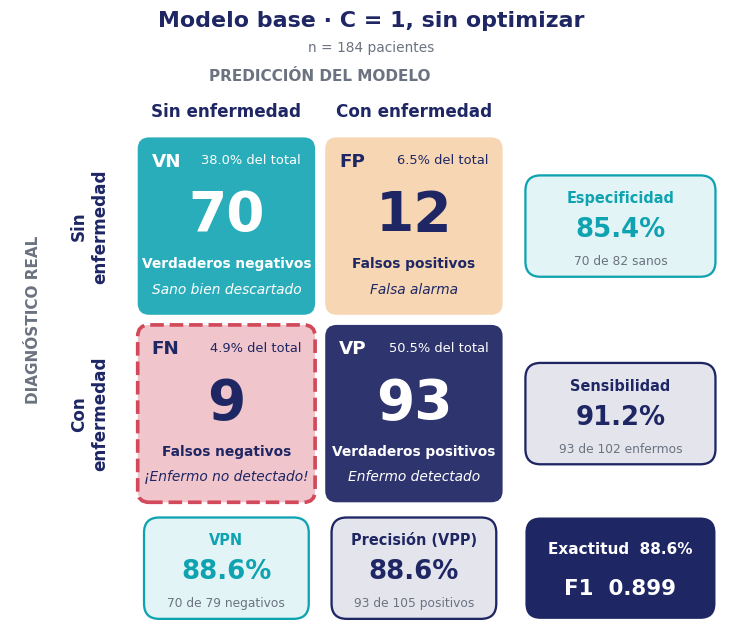

In [7]:
modelo_base = crear_pipeline()
modelo_base.fit(X_train, y_train)

y_pred_base  = modelo_base.predict(X_test)
y_proba_base = modelo_base.predict_proba(X_test)[:, 1]
metricas_base = calcular_metricas(y_test, y_pred_base, y_proba_base)

mostrar_metricas(metricas_base, "Modelo base (prueba)")
graficar_matriz_confusion(y_test, y_pred_base, "Modelo base · C = 1, sin optimizar")
plt.show()

> 🩺 **Lee la matriz como clínico:** la celda roja punteada (**FN**) son pacientes con enfermedad cardiaca que el modelo mandaría a casa. Las métricas en los márgenes se leen por **fila** (sensibilidad, especificidad) y por **columna** (VPN, precisión).

---
## 4 · El diccionario de hiperparámetros

Un **hiperparámetro** no se aprende de los datos: lo decides tú **antes** de entrenar. En `LogisticRegression` los tres más importantes son:

| Hiperparámetro | Qué controla | Intuición clínica |
|---|---|---|
| **`C`** | Inverso de la fuerza de regularización. `C` pequeño = modelo más "simple" y prudente; `C` grande = el modelo se ajusta más a los datos de entrenamiento. | Un médico que se deja llevar por cada detalle raro de un expediente (C grande) vs. uno que solo confía en los signos más sólidos (C pequeño). |
| **`l1_ratio`** | Tipo de regularización: `0` = **L2 (Ridge)** encoge todos los coeficientes; `1` = **L1 (Lasso)** puede llevar coeficientes a **cero exacto** (elimina variables); valores intermedios = **Elastic-Net** (mezcla). | L1 funciona como un filtro que descarta estudios clínicos que no aportan. |
| **`class_weight`** | `None` = todos los pacientes pesan igual; `"balanced"` = compensa si una clase es menos frecuente. | Útil cuando hay pocos enfermos; aquí las clases están casi balanceadas (55 % / 45 %), así que la búsqueda dirá si vale la pena. |

> ⚙️ **Nota de versión:** desde scikit-learn 1.8 el tipo de penalización se controla solo con `l1_ratio` (el parámetro `penalty` quedó obsoleto). El `crear_pipeline()` de arriba ya contempla ambas versiones.

### 🔗 El prefijo `modelo__`
Como la regresión logística vive **dentro** de un `Pipeline`, `GridSearchCV` necesita saber a qué paso pertenece cada hiperparámetro. La regla es **`<nombre_del_paso>__<hiperparámetro>`** (dos guiones bajos). Nuestro paso se llama `"modelo"`, así que `C` se escribe `"modelo__C"`.

### 🔑 TODO 2 — Solución: diccionario `param_grid`

In [8]:
# 🔑 SOLUCIÓN TODO 2 ────────────────────────────────────────────────────
param_grid = {
    "modelo__C":            np.logspace(-3, 2, 11),   # 0.001 … 100, pasos de media década
    "modelo__l1_ratio":     [0.0, 0.5, 1.0],          # L2 · Elastic-Net · L1
    "modelo__class_weight": [None, "balanced"],
}

In [9]:
# ✅ VERIFICACIÓN TODO 2
assert isinstance(param_grid, dict), "param_grid debe ser un diccionario {'modelo__hiperparámetro': [valores]}."
_sin_prefijo = [k for k in param_grid if not k.startswith("modelo__")]
assert not _sin_prefijo, f"Estas claves no llevan el prefijo 'modelo__': {_sin_prefijo}"
_faltan = [k for k in ["modelo__C", "modelo__l1_ratio", "modelo__class_weight"] if k not in param_grid]
assert not _faltan, f"Faltan estos hiperparámetros: {_faltan}"

_C = np.asarray(param_grid["modelo__C"], dtype=float)
assert len(_C) >= 6, f"Incluye al menos 6 valores de C (tienes {len(_C)})."
assert _C.min() <= 0.0011 and _C.max() >= 99.9, f"C debe cubrir de 0.001 a 100 (tu rango: {_C.min():g} – {_C.max():g})."
_l1 = {float(v) for v in param_grid["modelo__l1_ratio"]}
assert {0.0, 0.5, 1.0} <= _l1, f"l1_ratio debe incluir 0, 0.5 y 1 (tienes {sorted(_l1)})."
_cw = list(param_grid["modelo__class_weight"])
assert None in _cw and "balanced" in _cw, "class_weight debe incluir None y 'balanced'."
crear_pipeline().set_params(**{k: list(v)[0] for k, v in param_grid.items()})   # ¿nombres válidos?

_n_comb = int(np.prod([len(list(v)) for v in param_grid.values()]))
print("✅ Diccionario válido")
for k, v in param_grid.items():
    print(f"   {k:<22} {len(list(v)):>2} valores: {[round(float(x), 4) if isinstance(x, (int, float, np.number)) and not isinstance(x, bool) else x for x in list(v)]}")
print(f"\n   {_n_comb} combinaciones × {validacion.get_n_splits()} pliegues = {_n_comb * validacion.get_n_splits()} entrenamientos")

✅ Diccionario válido
   modelo__C              11 valores: [0.001, 0.0032, 0.01, 0.0316, 0.1, 0.3162, 1.0, 3.1623, 10.0, 31.6228, 100.0]
   modelo__l1_ratio        3 valores: [0.0, 0.5, 1.0]
   modelo__class_weight    2 valores: [None, 'balanced']

   66 combinaciones × 5 pliegues = 330 entrenamientos


> **🧑‍🏫 Nota docente — TODO 2**
> - Error más común: olvidar el prefijo (`"C"` en vez de `"modelo__C"`) → `ValueError: Invalid parameter 'C' for estimator Pipeline`. La verificación lo atrapa antes de lanzar la búsqueda.
> - `np.logspace(-3, 2, 6)` es la respuesta mínima aceptable. Con esa rejilla el ganador en esta partición es `C = 0.1, l1_ratio = 0.5` y la matriz de prueba resulta **idéntica** a la del modelo base: excelente ejemplo de que optimizar no garantiza mejorar.
> - Aceptar rejillas más finas o con más valores de `l1_ratio`; penalizar solo si no cumplen los tres requisitos.

---
## 5 · Búsqueda en rejilla con validación cruzada

`GridSearchCV` entrena el pipeline **una vez por cada combinación y por cada pliegue**, y se queda con la combinación de mejor **puntaje promedio en validación**. Al final re-entrena automáticamente el ganador con todo el conjunto de entrenamiento (`refit=True`).

La pregunta clave es **¿qué significa "mejor"?** Eso lo decide el parámetro `scoring`:

| `scoring` | Optimiza… | ¿Riesgo? |
|---|---|---|
| `"accuracy"` | aciertos totales | ignora qué tipo de error se comete |
| `"recall"` | solo sensibilidad | 🤔 lo veremos en un experimento más adelante… |
| `"f1"` | equilibrio precisión–sensibilidad | no considera los verdaderos negativos |
| `"roc_auc"` | capacidad de ordenar enfermos sobre sanos | no depende del umbral 0.5 |
| `"balanced_accuracy"` | promedio de sensibilidad y especificidad | trata ambos errores como igual de graves |

### 🔑 TODO 3 y 4 — Solución: métrica y `GridSearchCV`

In [10]:
# 🔑 SOLUCIÓN TODO 3 y 4 ────────────────────────────────────────────────
metrica_busqueda = "f1"
busqueda = GridSearchCV(estimator=crear_pipeline(),
                        param_grid=param_grid,
                        scoring=metrica_busqueda,
                        cv=validacion,
                        n_jobs=-1)
busqueda.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__C': array([1.0000...00000000e+02]), 'modelo__class_weight': [None, 'balanced'], 'modelo__l1_ratio': [0.0, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation 

**✍️ Justificación modelo (TODO 3):** elegimos **F1** porque en triaje cardiológico importa no dejar enfermos sin detectar (sensibilidad), pero sin llenar la consulta especializada de falsas alarmas (precisión); F1 castiga a un modelo que sacrifique cualquiera de las dos. Además, la sensibilidad se afinará después moviendo el umbral (Parte 7), de modo que la búsqueda no necesita optimizarla sola.

> **🧑‍🏫 Nota docente — criterios para el TODO 3**
> - **Puntaje completo:** `f1`, `roc_auc` o `balanced_accuracy` con una justificación que mencione el costo clínico de FN y/o FP.
> - `accuracy` con justificación razonable ("clases casi balanceadas"): 7/10.
> - `recall` **sin** advertir el riesgo de un modelo degenerado: 5/10 (el experimento de la Parte 6 les mostrará por qué).
> - Con la rejilla de la solución, las cinco métricas coinciden en `C ≈ 0.316`, pero no en lo demás: `roc_auc` elige `class_weight='balanced', l1_ratio = 1` (L1 pura); `accuracy` y `balanced_accuracy` eligen L2 (`l1_ratio = 0`); `f1` elige Elastic-Net (`l1_ratio = 0.5`). Diferentes métricas coronan distintos ganadores.

In [11]:
# ✅ VERIFICACIÓN TODO 3 y 4 + resumen de la búsqueda
assert metrica_busqueda in ["accuracy", "recall", "f1", "roc_auc", "balanced_accuracy"], \
    "metrica_busqueda debe ser una de las cinco opciones de la tabla."
assert isinstance(busqueda, GridSearchCV), "busqueda debe ser un objeto GridSearchCV."
assert hasattr(busqueda, "best_estimator_"), "Falta entrenar la búsqueda con .fit(X_train, y_train)."
assert busqueda.n_splits_ == 5, "Usa cv=validacion (5 pliegues estratificados)."

# Comparación JUSTA: el modelo base evaluado con la misma métrica y los mismos pliegues
_cv_base = cross_val_score(crear_pipeline(), X_train, y_train, cv=validacion, scoring=metrica_busqueda)
_std_mejor = busqueda.cv_results_["std_test_score"][busqueda.best_index_]
print(f"Métrica optimizada: {metrica_busqueda}\n")
print(f"   Modelo base (C=1, L2)     {_cv_base.mean():.4f} ± {_cv_base.std():.4f}")
print(f"   Mejor de la búsqueda      {busqueda.best_score_:.4f} ± {_std_mejor:.4f}")
print("\nMejores hiperparámetros:")
for k, v in busqueda.best_params_.items():
    print(f"   {k.replace('modelo__', ''):<14} {round(v, 4) if isinstance(v, float) else v}")

Métrica optimizada: f1

   Modelo base (C=1, L2)     0.8633 ± 0.0226
   Mejor de la búsqueda      0.8660 ± 0.0192

Mejores hiperparámetros:
   C              0.3162
   class_weight   None
   l1_ratio       0.5


In [12]:
# Las 10 mejores combinaciones (ranking por puntaje promedio de validación)
_res = pd.DataFrame(busqueda.cv_results_)
_cols = [c for c in _res.columns if c.startswith("param_")]
top10 = (_res.sort_values("rank_test_score")
             [["rank_test_score"] + _cols + ["mean_test_score", "std_test_score"]]
             .rename(columns=lambda c: c.replace("param_modelo__", ""))
             .head(10).reset_index(drop=True))
top10.style.format({"C": "{:.4g}", "mean_test_score": "{:.4f}", "std_test_score": "{:.4f}"}) \
     .background_gradient(subset=["mean_test_score"], cmap="GnBu")

,rank_test_score,C,class_weight,l1_ratio,mean_test_score,std_test_score
0,1,0.3162,nan,0.500000,0.8660,0.0192
1,2,0.1,nan,0.500000,0.8657,0.0191
2,3,0.3162,nan,0.000000,0.8657,0.0205
3,4,0.3162,nan,1.000000,0.8650,0.0204
4,5,0.1,nan,1.000000,0.8650,0.0231
5,6,0.03162,nan,0.000000,0.8637,0.0229
6,7,100,nan,1.000000,0.8633,0.0226
7,7,100,nan,0.500000,0.8633,0.0226
8,7,100,nan,0.000000,0.8633,0.0226
9,7,10,nan,0.500000,0.8633,0.0226


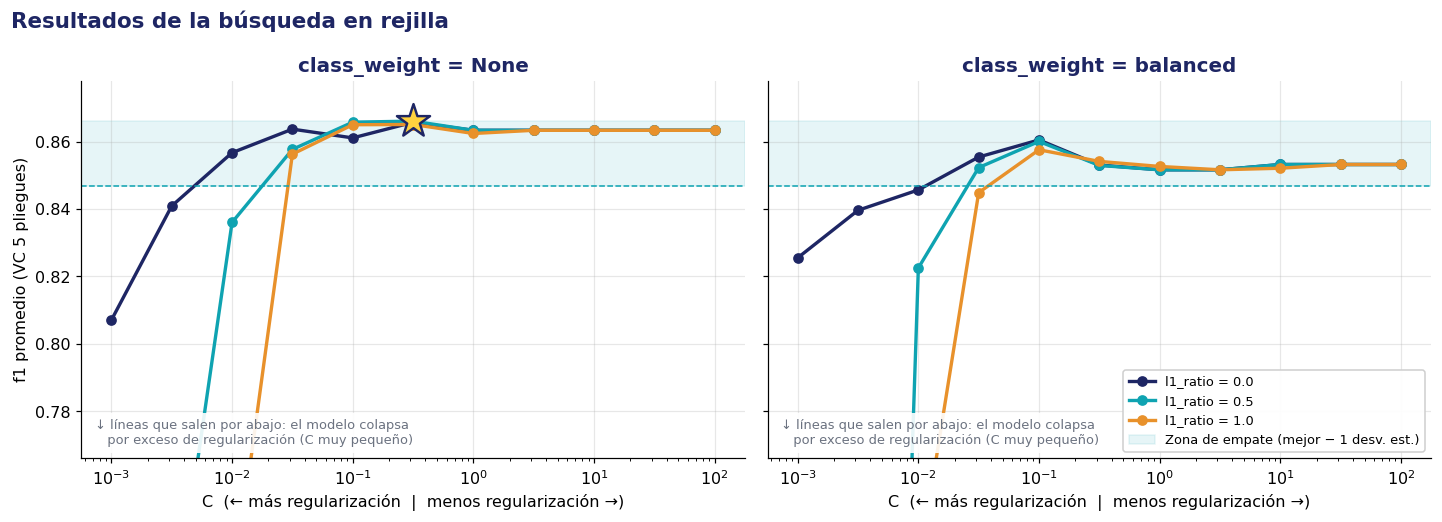

In [13]:
graficar_busqueda(busqueda)

> 📈 **Cómo leer la gráfica:** cada línea es una combinación de `l1_ratio`; el eje X es `C` en escala logarítmica. La ⭐ es el ganador. La **franja turquesa** marca la *zona de empate*: toda configuración que caiga dentro está a menos de una desviación estándar del ganador, así que **no podemos afirmar que sea peor**. Observa también qué pasa a la izquierda (C muy pequeño): el modelo se "apaga" por exceso de regularización.

---
## 6 · Evaluación del modelo optimizado en el conjunto de prueba

### 🔑 TODO 5 — Solución: evaluación del ganador

In [14]:
# 🔑 SOLUCIÓN TODO 5 ────────────────────────────────────────────────────
mejor_modelo  = busqueda.best_estimator_
y_pred_opt    = mejor_modelo.predict(X_test)
y_proba_opt   = mejor_modelo.predict_proba(X_test)[:, 1]
metricas_opt  = calcular_metricas(y_test, y_pred_opt, y_proba_opt)

In [15]:
# ✅ VERIFICACIÓN TODO 5
assert mejor_modelo is busqueda.best_estimator_, "mejor_modelo debe ser busqueda.best_estimator_ (no lo re-entrenes a mano)."
assert y_pred_opt is not None and len(y_pred_opt) == len(y_test), "Calcula y_pred_opt sobre X_test."
assert y_proba_opt is not None and np.ndim(y_proba_opt) == 1 and np.all((y_proba_opt >= 0) & (y_proba_opt <= 1)), \
    "y_proba_opt debe ser un vector de probabilidades de la clase 1 → predict_proba(X_test)[:, 1]"
assert metricas_opt is not None, "Calcula metricas_opt con calcular_metricas."
mostrar_metricas(metricas_opt, "Modelo optimizado (prueba)")

── Modelo optimizado (prueba) ──────────────────
   VP=95  FN=7  VN=71  FP=11
   Exactitud         0.902  ██████████████████
   Sensibilidad      0.931  ███████████████████
   Especificidad     0.866  █████████████████
   Precisión (VPP)   0.896  ██████████████████
   F1                0.913  ██████████████████
   AUC-ROC           0.933  ███████████████████


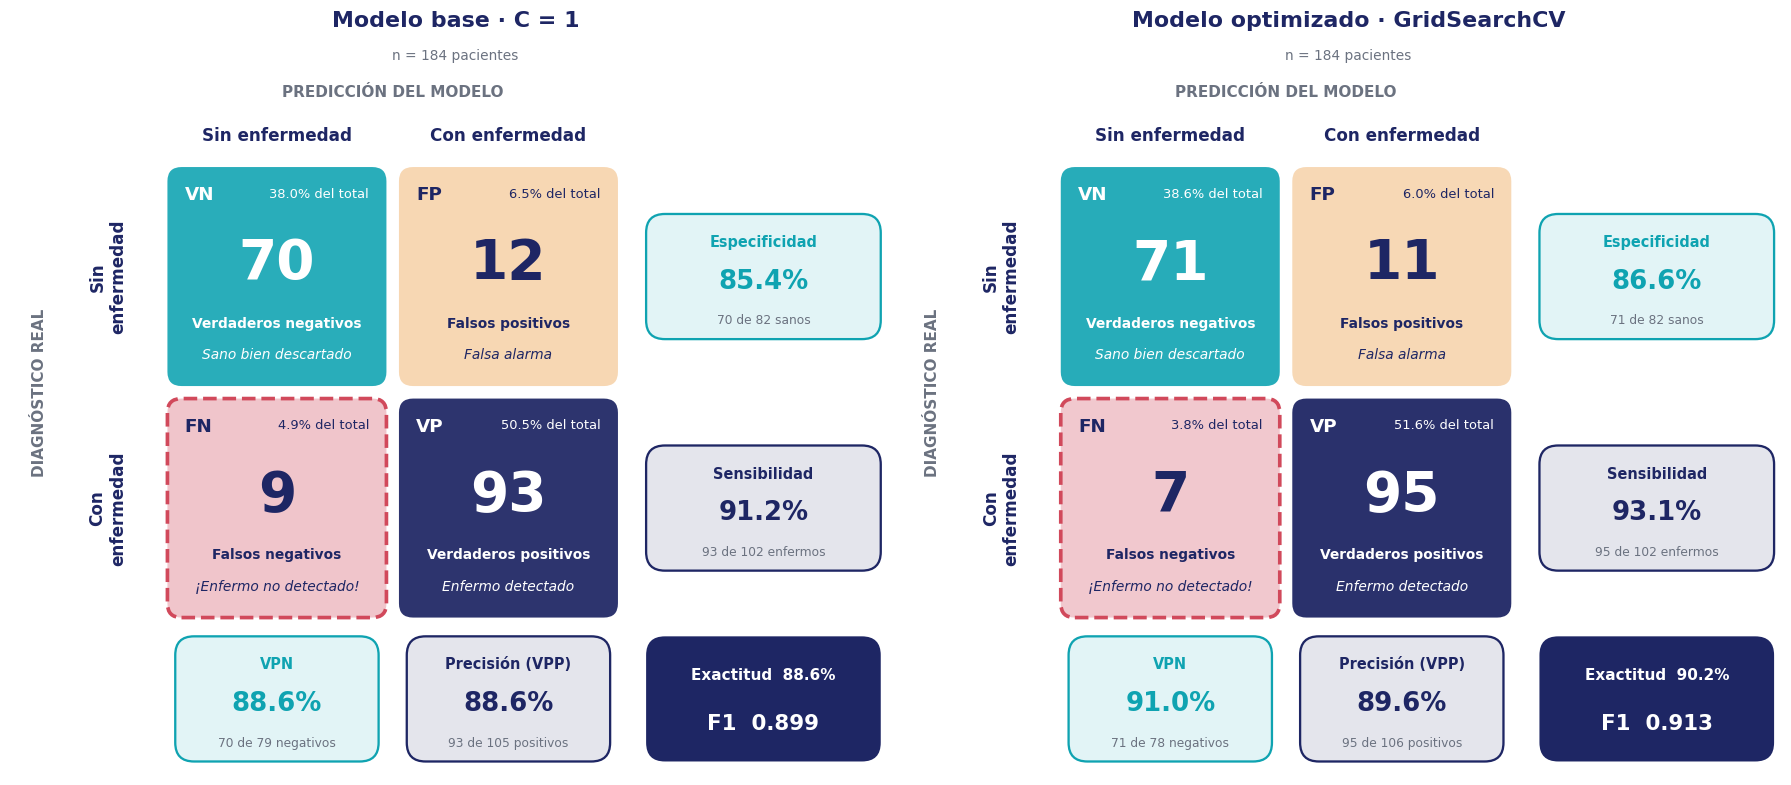

In [16]:
graficar_matrices_lado_a_lado([
    (y_test, y_pred_base, "Modelo base · C = 1"),
    (y_test, y_pred_opt,  "Modelo optimizado · GridSearchCV"),
])

,Base,Optimizado
Exactitud,0.886,0.902
Sensibilidad,0.912,0.931
Especificidad,0.854,0.866
Precisión (VPP),0.886,0.896
F1,0.899,0.913
AUC-ROC,0.932,0.933
Enfermos no detectados (FN),9,7
Falsas alarmas (FP),12,11


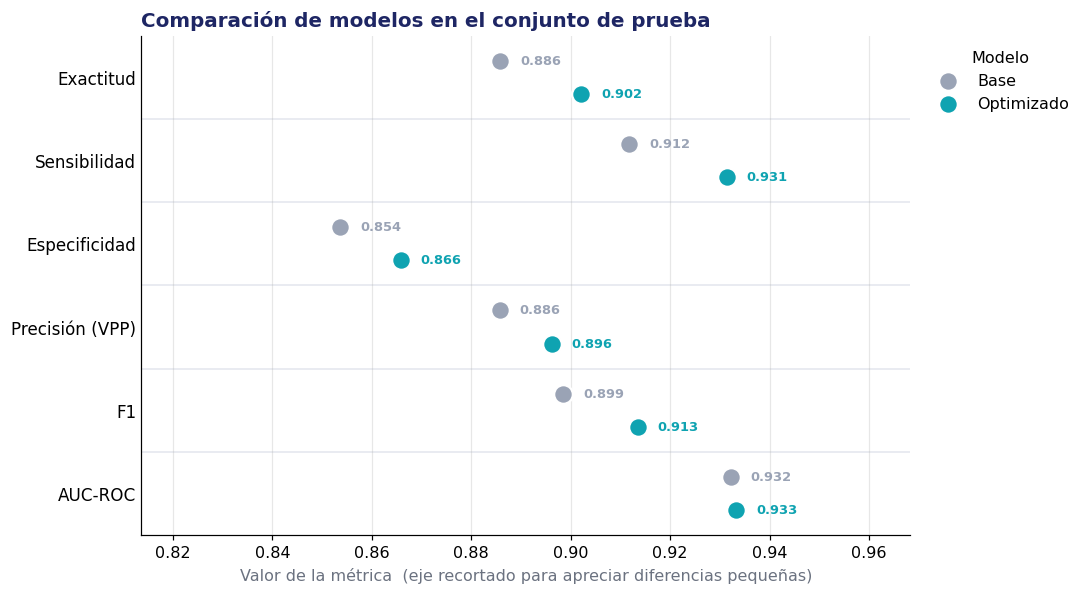

In [17]:
resultados = {"Base": metricas_base, "Optimizado": metricas_opt}
display(tabla_comparativa(resultados))
graficar_comparacion_metricas(resultados)

### 🔬 ¿Qué cambió dentro del modelo?
La regularización no solo cambia las métricas: cambia **qué variables usa el modelo**. Si tu ganador tiene `l1_ratio > 0`, algunas variables pueden quedar con coeficiente **cero exacto** (el modelo las descartó).

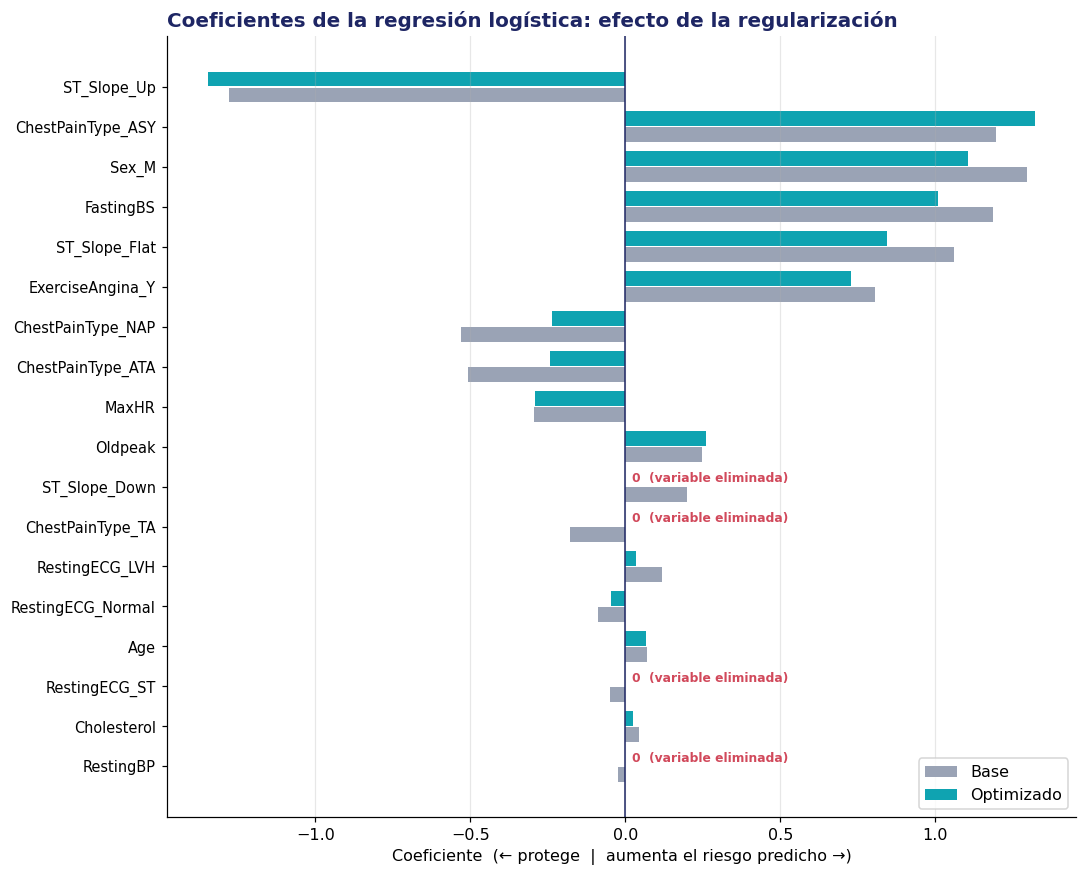

Variables eliminadas por el modelo optimizado: ['RestingBP', 'RestingECG_ST', 'ChestPainType_TA', 'ST_Slope_Down']


In [18]:
coeficientes = graficar_coeficientes({"Base": modelo_base, "Optimizado": mejor_modelo})
eliminadas = coeficientes.index[coeficientes["Optimizado"] == 0].tolist()
print("Variables eliminadas por el modelo optimizado:", eliminadas if eliminadas else "ninguna")

> **🧑‍🏫 Nota docente — honestidad pedagógica en la comparación**
> - En esta ejecución el ganador es `C ≈ 0.316, l1_ratio = 0.5, class_weight = None`. En prueba pasa de **9 → 7 falsos negativos** y de **12 → 11 falsos positivos** (F1 0.899 → 0.913).
> - Pero en validación cruzada el F1 del ganador (≈ 0.866) supera al del modelo base (≈ 0.863) por **tres milésimas**, con desviaciones estándar de ≈ 0.02. **La mejora está dentro del ruido**: el modelo base ya estaba en la zona buena porque los datos están escalados y `C = 1` es un valor razonable. Presentarlo así evita que los alumnos crean que `GridSearchCV` "siempre mejora".
> - Lo que sí aporta la búsqueda: **certeza** de que no dejamos rendimiento sobre la mesa, y un modelo algo más simple (Elastic-Net elimina variables poco informativas; revisar la gráfica de coeficientes).
> - 2 falsos negativos menos en 102 enfermos equivalen a ~2 de cada 100 enfermos adicionales detectados; clínicamente relevante, estadísticamente frágil con un conjunto de prueba de 184 pacientes.

---
## 🧪 Experimento guiado: la trampa de optimizar solo la sensibilidad *(ya resuelto — ejecuta y observa)*

"En medicina lo más importante es no dejar ir a un enfermo… ¡entonces optimicemos solo la sensibilidad!" Veamos qué pasa si le pedimos a `GridSearchCV` exactamente eso.

Ganador al optimizar SOLO sensibilidad: {'C': 0.001, 'class_weight': None, 'l1_ratio': 1.0}
Sensibilidad promedio en validación: 1.000


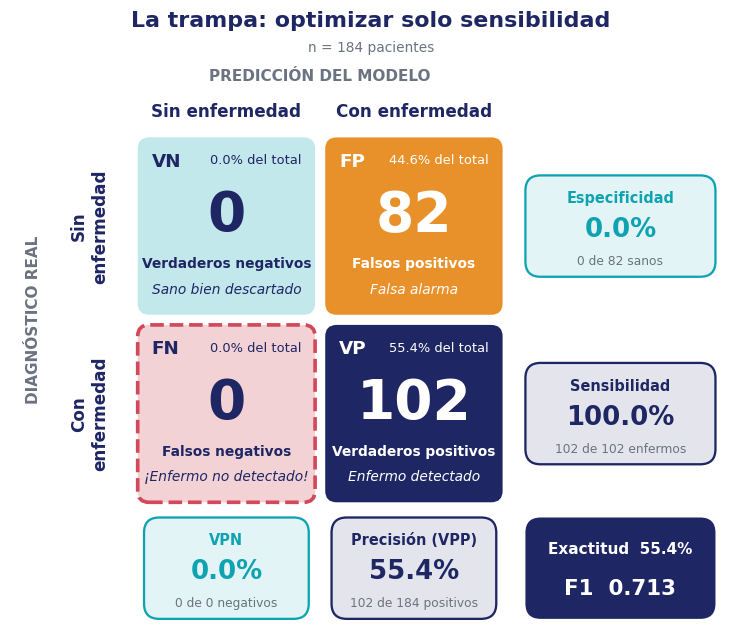

In [19]:
busqueda_trampa = GridSearchCV(
    crear_pipeline(),
    {"modelo__C": [0.001, 0.01, 0.1, 1, 10, 100],
     "modelo__l1_ratio": [0.0, 1.0],
     "modelo__class_weight": [None, "balanced"]},
    scoring="recall", cv=validacion, n_jobs=-1,
).fit(X_train, y_train)

print("Ganador al optimizar SOLO sensibilidad:", {k.replace("modelo__", ""): v for k, v in busqueda_trampa.best_params_.items()})
print(f"Sensibilidad promedio en validación: {busqueda_trampa.best_score_:.3f}")

y_pred_trampa  = busqueda_trampa.predict(X_test)
metricas_trampa = calcular_metricas(y_test, y_pred_trampa, busqueda_trampa.predict_proba(X_test)[:, 1])
graficar_matriz_confusion(y_test, y_pred_trampa, "La trampa: optimizar solo sensibilidad")
plt.show()

> 🤔 **Piénsalo:** ¿de qué le serviría este modelo al servicio de cardiología? ¿Qué métrica(s) lo delatan de inmediato? (Lo responderás en las preguntas finales.)

> **🧑‍🏫 Nota docente — experimento trampa**
> Con `C = 0.001` y `l1_ratio = 1` la penalización L1 lleva **todos** los coeficientes a cero: el modelo solo conserva el intercepto y predice "con enfermedad" para todos (la clase mayoritaria). Sensibilidad = 100 %, especificidad = 0 %, AUC = 0.5 (no distingue a nadie: equivale a lanzar una moneda). Clínicamente: los 82 sanos de prueba serían enviados a estudios especializados. Buen cierre: *"una métrica sola siempre se puede hacer trampa; por eso miramos la matriz completa"*.

---
## 7 · Ajuste del umbral de decisión

Por defecto, `predict()` dice "con enfermedad" cuando la probabilidad es **≥ 0.50**. Pero ese 0.50 **también es una decisión**: si bajamos el umbral, detectamos más enfermos (↑ sensibilidad) a costa de más falsas alarmas (↓ especificidad).

⚠️ **Regla de oro:** el umbral se elige con datos de **entrenamiento** (mediante predicciones de validación cruzada), **nunca** mirando el conjunto de prueba. Si lo eligiéramos con prueba, estaríamos haciendo trampa y la evaluación final sería optimista.

La siguiente celda *(ya resuelta)* obtiene, para cada paciente de entrenamiento, la probabilidad que le asigna un modelo que **no lo vio** durante su entrenamiento (`cross_val_predict`), y calcula la sensibilidad y especificidad para 91 umbrales entre 0.05 y 0.95.

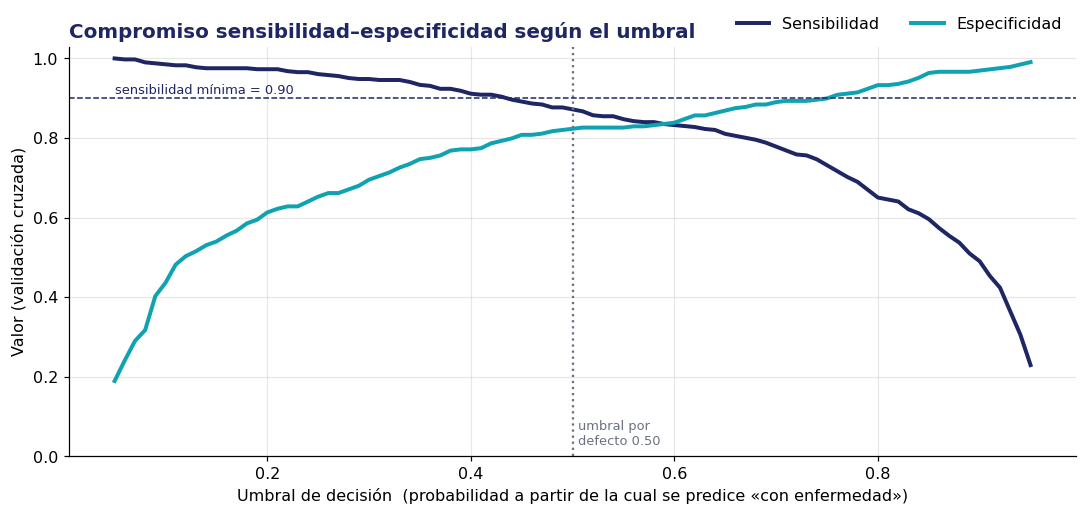

In [20]:
proba_cv = cross_val_predict(mejor_modelo, X_train, y_train, cv=validacion, method="predict_proba")[:, 1]

umbrales = np.round(np.arange(0.05, 0.951, 0.01), 2)
sens_cv  = np.array([recall_score(y_train, (proba_cv >= u).astype(int)) for u in umbrales])
espec_cv = np.array([recall_score(y_train, (proba_cv >= u).astype(int), pos_label=0) for u in umbrales])

SENSIBILIDAD_MINIMA = 0.90   # requisito del servicio de cardiología
graficar_umbral(umbrales, sens_cv, espec_cv, sens_minima=SENSIBILIDAD_MINIMA)

### 🔑 TODO 6 — Solución: umbral de decisión

In [21]:
# 🔑 SOLUCIÓN TODO 6 ────────────────────────────────────────────────────
umbral_elegido  = umbrales[sens_cv >= SENSIBILIDAD_MINIMA].max()
y_pred_umbral   = (y_proba_opt >= umbral_elegido).astype(int)
metricas_umbral = calcular_metricas(y_test, y_pred_umbral, y_proba_opt)

✅ Umbral elegido: 0.43   (en validación: sensibilidad 0.904, especificidad 0.793)


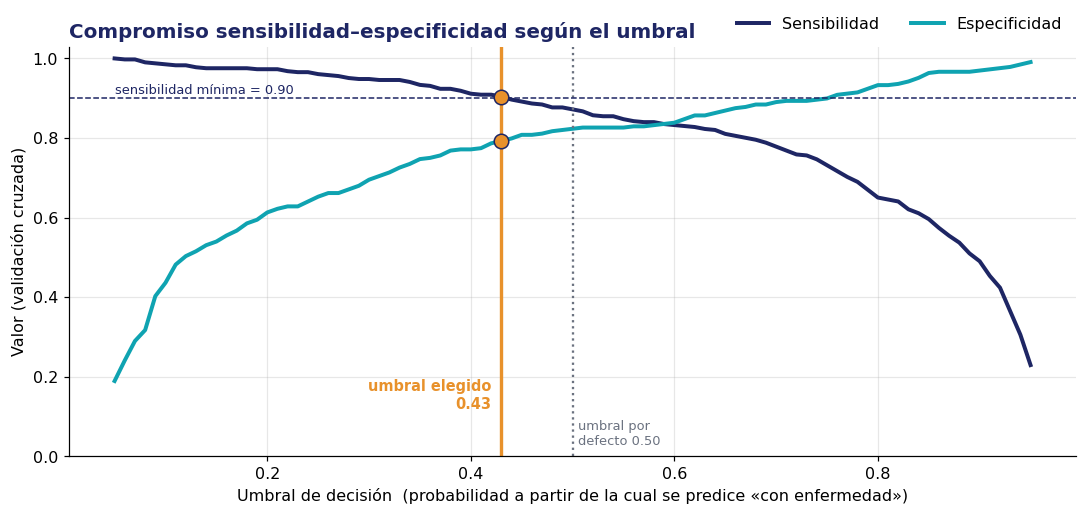

In [22]:
# ✅ VERIFICACIÓN TODO 6
assert umbral_elegido is not None, "Define umbral_elegido."
_umbral_ok = umbrales[sens_cv >= SENSIBILIDAD_MINIMA].max()
assert np.isclose(umbral_elegido, _umbral_ok), \
    f"Tu umbral ({umbral_elegido}) no es el MÁS ALTO que cumple sensibilidad ≥ {SENSIBILIDAD_MINIMA} en validación."
assert y_pred_umbral is not None and set(np.unique(y_pred_umbral)) <= {0, 1}, "y_pred_umbral debe contener solo 0 y 1."
assert np.array_equal(y_pred_umbral, (y_proba_opt >= umbral_elegido).astype(int)), \
    "Aplica el umbral a y_proba_opt (probabilidades de PRUEBA del modelo optimizado)."
_i = int(np.argmin(np.abs(umbrales - umbral_elegido)))
print(f"✅ Umbral elegido: {umbral_elegido:.2f}   (en validación: sensibilidad {sens_cv[_i]:.3f}, especificidad {espec_cv[_i]:.3f})")
graficar_umbral(umbrales, sens_cv, espec_cv, umbral_elegido=umbral_elegido, sens_minima=SENSIBILIDAD_MINIMA)

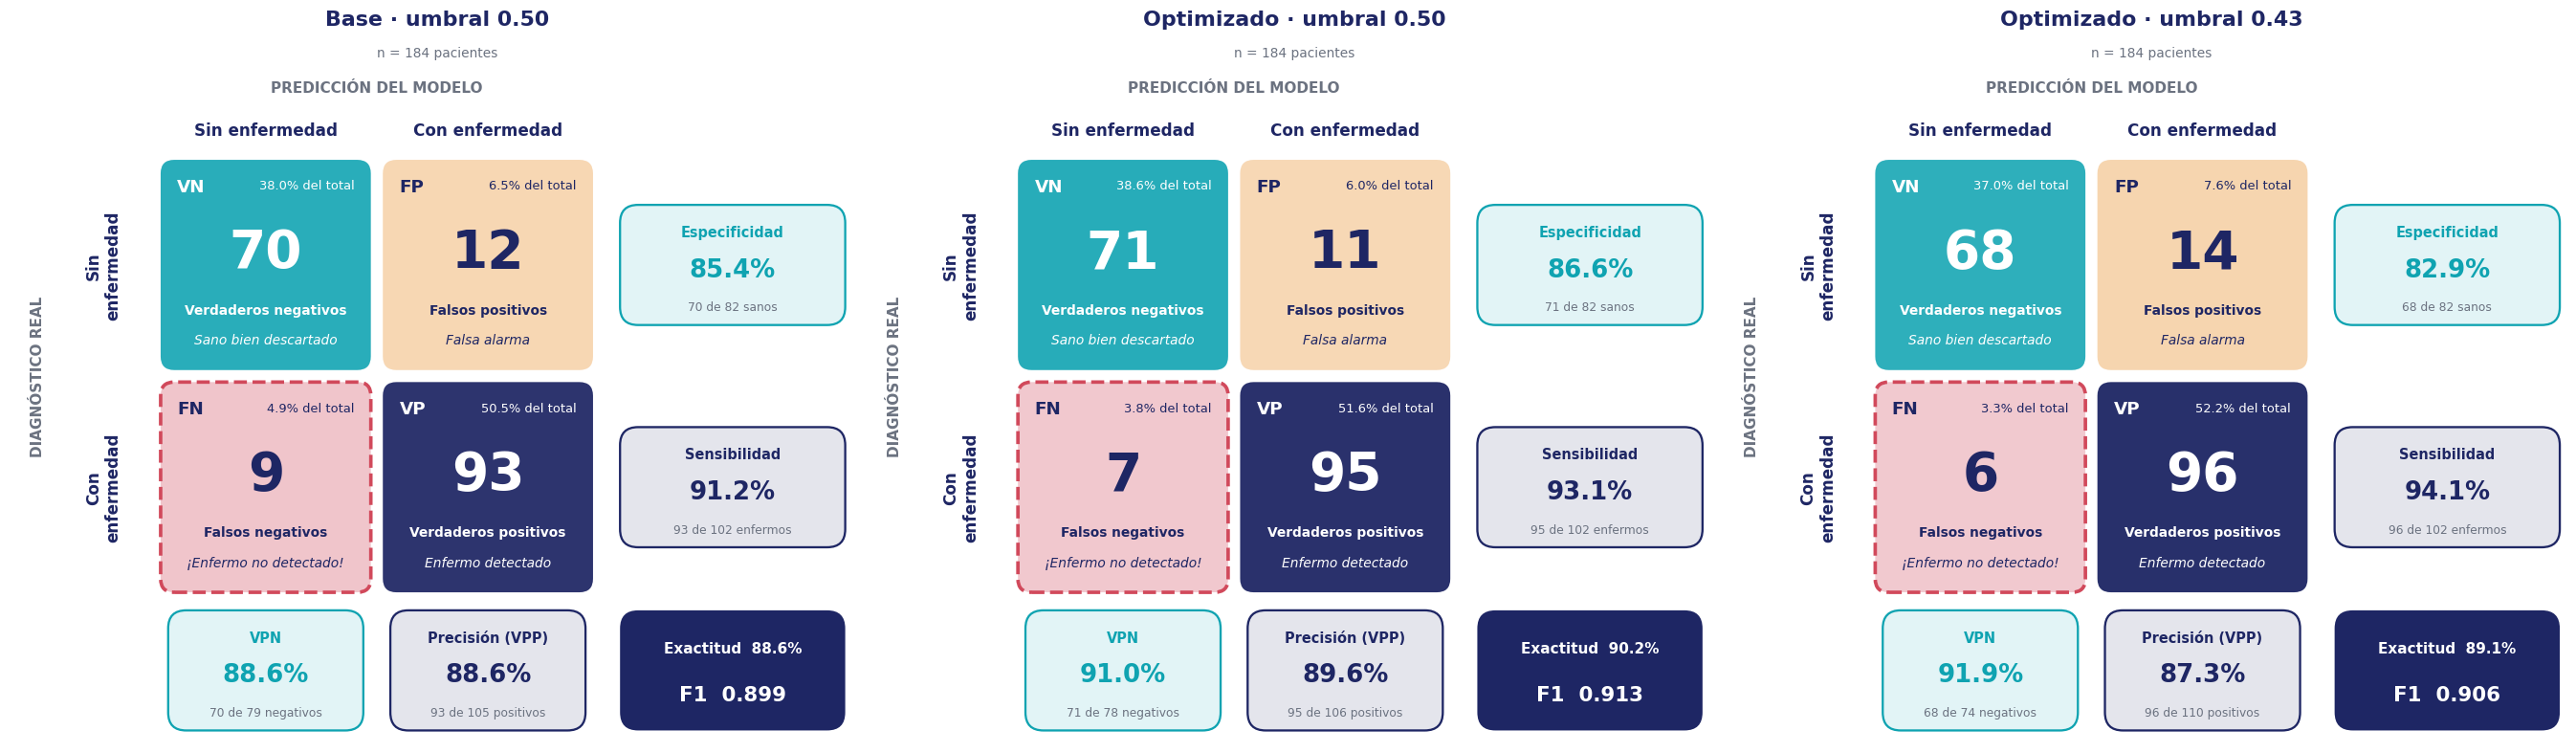

In [23]:
graficar_matrices_lado_a_lado([
    (y_test, y_pred_base,   "Base · umbral 0.50"),
    (y_test, y_pred_opt,    "Optimizado · umbral 0.50"),
    (y_test, y_pred_umbral, f"Optimizado · umbral {umbral_elegido:.2f}"),
])

,Base,Optimizado,Optimizado + umbral 0.43
Exactitud,0.886,0.902,0.891
Sensibilidad,0.912,0.931,0.941
Especificidad,0.854,0.866,0.829
Precisión (VPP),0.886,0.896,0.873
F1,0.899,0.913,0.906
AUC-ROC,0.932,0.933,0.933
Enfermos no detectados (FN),9,7,6
Falsas alarmas (FP),12,11,14


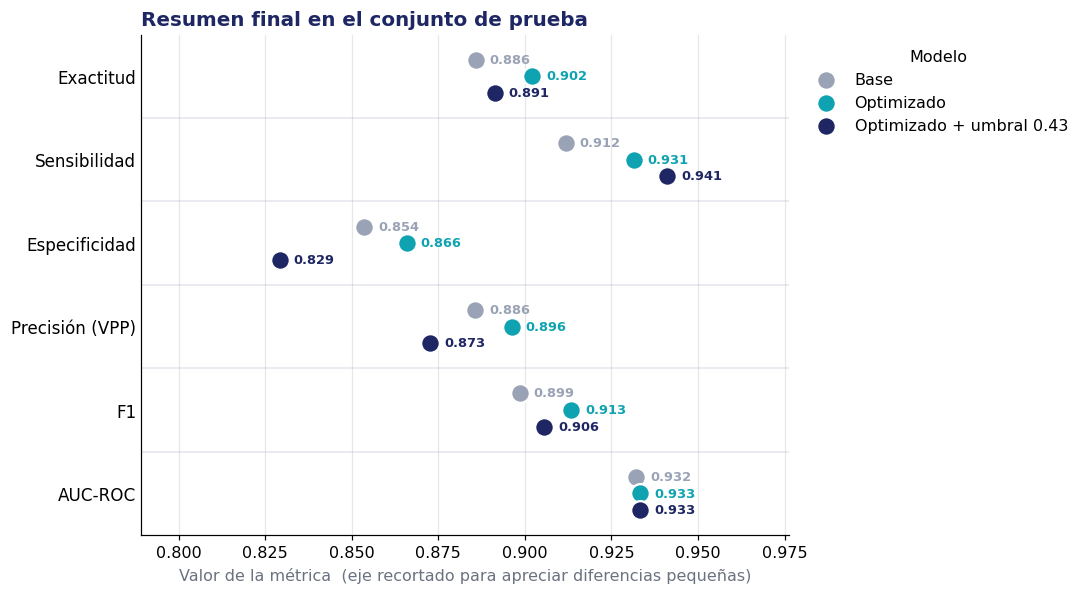

In [24]:
resultados_finales = {"Base": metricas_base, "Optimizado": metricas_opt,
                      f"Optimizado + umbral {umbral_elegido:.2f}": metricas_umbral}
display(tabla_comparativa(resultados_finales))
graficar_comparacion_metricas(resultados_finales, "Resumen final en el conjunto de prueba")

> **🧑‍🏫 Nota docente — umbral**
> - En esta ejecución el umbral elegido es **0.43** (en validación cruzada: sensibilidad 0.872 → 0.904, especificidad 0.823 → 0.793 respecto a 0.50). En prueba: FN **7 → 6**, FP **11 → 14** (sensibilidad 0.931 → 0.941, especificidad 0.866 → 0.829).
> - Momento de honestidad: en prueba el cambio de umbral rescata **un solo** enfermo a cambio de tres falsas alarmas. El modelo optimizado ya superaba el 90 % de sensibilidad en prueba con 0.50; el umbral garantiza la meta *en validación*, que es lo que podemos controlar sin mirar prueba.
> - El AUC no cambia al mover el umbral (0.933 en ambos): el umbral no cambia **cómo ordena** el modelo, solo **dónde corta**. Pregunta rápida para la clase.
> - Si un alumno obtiene el umbral mirando `y_test`, penalizar aunque "le salga mejor": es fuga de información.
> - Comprobación hecha al preparar la práctica: con `SENSIBILIDAD_MINIMA = 0.95` el umbral baja a ≈ 0.28 y en prueba la sensibilidad **no sube** respecto a 0.90 (sigue en 0.941) mientras la especificidad cae a ≈ 0.71. Con 102 enfermos en prueba, cada paciente vale ~1 punto porcentual: las metas de validación no se trasladan exactamente a prueba.

---
## 8 · Preguntas de análisis *(20 pts — 4 pts cada una)*
Responde en las celdas de texto usando **tus propios resultados** (cita números de tus tablas y matrices).

**P1.** Compara el modelo base contra el optimizado en prueba: ¿cuántos enfermos dejó de detectar cada uno (FN)? Usando la gráfica de la búsqueda y la *zona de empate*, ¿dirías que la mejora es confiable o podría deberse al azar? Explica.

**P2.** ¿Qué valores de `C` y `l1_ratio` eligió tu búsqueda? Explica con tus palabras qué significa ese nivel de regularización y qué variables clínicas eliminó (o no) el modelo según la gráfica de coeficientes.

**P3.** En el experimento de la trampa, ¿por qué optimizar solo la sensibilidad produjo un modelo inútil? ¿Qué dos métricas lo delatan de inmediato y por qué?

**P4.** Al bajar el umbral, ¿qué ganaste y qué perdiste (en número de pacientes)? ¿Recomendarías ese umbral para **triaje** (decidir quién pasa a estudios no invasivos)? ¿Y si el modelo decidiera directamente un **cateterismo cardiaco** (procedimiento invasivo con riesgos)?

**P5.** ¿Por qué elegimos el umbral con predicciones de validación cruzada sobre **entrenamiento** y no directamente con el conjunto de **prueba**?

### 🔑 Respuestas modelo (basadas en esta ejecución)

**P1.** El modelo base deja **9** enfermos sin detectar y el optimizado **7** (y las falsas alarmas bajan de 12 a 11). Sin embargo, en validación cruzada el F1 del ganador (≈ 0.866) apenas supera al del base (≈ 0.863), con desviaciones estándar cercanas a 0.02; muchas configuraciones —incluida la región de `C = 1`— quedan dentro de la zona de empate. La mejora observada en prueba es real para *esta* partición, pero **no es estadísticamente confiable**: equivale a 2 pacientes y podría invertirse con otra partición. Conclusión: el modelo base ya estaba bien ajustado; la búsqueda confirma que no hay una configuración claramente superior.

**P2.** `C ≈ 0.316` y `l1_ratio = 0.5` (Elastic-Net), sin pesos de clase. Un `C` menor que 1 significa **más regularización** que el modelo base: se le pide al modelo que confíe menos en patrones finos del entrenamiento y mantenga coeficientes pequeños. La mitad L1 lleva a **cero exacto** cuatro coeficientes poco informativos: presión arterial en reposo (`RestingBP`), anomalía ST-T en el ECG en reposo (`RestingECG_ST`), angina típica (`ChestPainType_TA`) y pendiente ST descendente (`ST_Slope_Down`); el resto se encoge. En cambio, los predictores fuertes —pendiente ST (`ST_Slope`), dolor torácico asintomático (`ChestPainType_ASY`), sexo, glucosa en ayuno y angina de esfuerzo— conservan su peso.

**P3.** Con `C = 0.001` y L1 pura, la regularización es tan fuerte que **todos** los coeficientes valen cero y el modelo predice "con enfermedad" para cualquier paciente. Así nunca deja ir a un enfermo (sensibilidad = 100 %), pero tampoco descarta a ningún sano. Lo delatan: **especificidad = 0 %** (0 de 82 sanos descartados) y **AUC = 0.5** (no ordena mejor que una moneda); también el VPN, que no puede calcularse porque no hay ningún negativo. Enseñanza: una métrica aislada se puede "ganar" con un modelo trivial.

**P4.** Al pasar de 0.50 a 0.43, los FN bajan de 7 a 6 (se detecta **1** enfermo más) y los FP suben de 11 a 14 (**3** falsas alarmas más); la sensibilidad sube de 93.1 % a 94.1 % y la especificidad baja de 86.6 % a 82.9 %. Un buen alumno notará que en prueba la ganancia es pequeña porque el modelo ya superaba la meta con 0.50; el umbral asegura la meta en validación. Para **triaje** es razonable: una falsa alarma cuesta un ecocardiograma o una prueba de esfuerzo adicional, mientras que un falso negativo puede ser un evento coronario no atendido. Para decidir un **cateterismo** no: ahí cada falso positivo expone a un paciente sano a un procedimiento invasivo (sangrado, complicaciones vasculares, contraste), así que se preferiría un umbral más alto o, mejor aún, usar el modelo solo como apoyo y no como decisión final.

**P5.** Porque el conjunto de prueba debe simular pacientes **futuros** que el modelo nunca vio. Si usamos prueba para elegir el umbral, esa decisión se "ajusta" a esos 184 pacientes concretos y las métricas que reportamos después serían **optimistas** (fuga de información). Las predicciones de validación cruzada dan, para cada paciente de entrenamiento, una probabilidad calculada por un modelo que no lo vio, así que sirven para decidir sin tocar prueba.

### 📝 Rúbrica detallada (100 pts)

| Criterio | Pts | Puntaje completo | Deducciones típicas |
|---|:---:|---|---|
| TODO 1 · Métricas | 20 | Pasa la verificación usando funciones de `sklearn.metrics` | −5 por métrica incorrecta; −5 si calcula fórmulas a mano en lugar de usar sklearn |
| TODO 2 · Diccionario | 20 | Cumple los 3 requisitos, prefijo correcto, escala logarítmica | −10 si C no es logarítmico o no cubre 0.001–100; −5 por requisito faltante |
| TODO 3 · Métrica + justificación | 10 | Métrica defendible con argumento clínico (FN/FP) | Ver nota docente del TODO 3 |
| TODO 4 · GridSearchCV | 10 | Pipeline, `cv=validacion`, entrena solo con entrenamiento | −10 si entrena con prueba; −3 si no usa `validacion` |
| TODO 5 · Evaluación | 10 | Usa `best_estimator_`, probabilidades `[:, 1]` | −5 si re-entrena a mano; −3 si usa `predict` para el AUC |
| TODO 6 · Umbral | 10 | Umbral máximo que cumple la meta, aplicado a prueba | −10 si elige el umbral mirando `y_test` |
| Preguntas P1–P5 | 20 | Respuestas con números propios y razonamiento clínico | −2 por respuesta genérica sin datos; −4 por respuesta ausente o incorrecta |
| Notebook sin ejecutar o con errores | — | — | −10 |

---
# 🔁 Parte B · Los mismos pacientes, otras dos familias de modelos

Hasta aquí todo el trabajo giró alrededor de **una sola familia**: la regresión logística. Pero la pregunta clínica —*¿este paciente tiene enfermedad cardiaca?*— no obliga a usar esa familia. En esta segunda parte repetimos **exactamente la misma dinámica** con dos clasificadores muy distintos entre sí:

| Familia | Idea central en una línea | ¿Qué aprende de los datos? |
|---|---|---|
| **SVM** · máquinas de vectores de soporte | Traza la frontera que deja el **corredor más ancho** entre sanos y enfermos | Una frontera geométrica: recta o curva según el *kernel* |
| **Naive Bayes gaussiano** | Aplica el **teorema de Bayes** suponiendo que las variables son independientes entre sí | La distribución (media y varianza) de cada variable dentro de cada clase |

Para cada familia harás lo mismo que con la regresión logística:

1. Entrenar una versión **con los valores por defecto** (sin tocar ningún hiperparámetro) y mirar sus métricas.
2. Buscar sus **mejores hiperparámetros** con `GridSearchCV` y la misma validación cruzada de 5 pliegues.
3. Compararla en el **mismo conjunto de prueba**, que sigue sin tocarse.

> ⚠️ **Del lado de los datos no cambia nada.** Seguimos usando `X_train`, `X_test`, `y_train`, `y_test`, el mismo `preprocesador`, la misma `validacion` y **tu** función `calcular_metricas`, además de todas las gráficas de la Parte A (matrices de confusión, tabla comparativa, gráfica de la búsqueda). Esa es justamente la condición para que la comparación entre familias sea **justa**: lo único que cambia es el modelo.

> 📋 **Las instrucciones de la Parte A siguen vigentes:** ejecuta las celdas en orden, escribe solo entre las marcas `▼▼▼ TU CÓDIGO AQUÍ ▼▼▼` y `▲▲▲ FIN DE TU CÓDIGO ▲▲▲`, y abre las 💡 pistas únicamente si te atoras. La diferencia es que aquí hay **6 `✏️ TODO` más**, numerados B1 a B6, con su propia tabla de puntos.

| TODO | Tema | Puntos |
|:---:|---|:---:|
| B1 | SVM con valores por defecto | 10 |
| B2 | Rejilla de hiperparámetros del SVM | 15 |
| B3 | Búsqueda y evaluación del SVM optimizado | 15 |
| B4 | Naive Bayes con valores por defecto | 10 |
| B5 | Rejilla de hiperparámetros de Naive Bayes | 15 |
| B6 | Búsqueda y evaluación de Naive Bayes optimizado | 15 |
| — | Preguntas de análisis B (P6–P10) | 20 |
| | **Total de la Parte B** | **100** |

> ## 🔑 PARTE B — VERSIÓN DOCENTE
> Las celdas 🔑 sustituyen a los `✏️ TODO` del alumno y las 🧑‍🏫 no existen en su versión.
>
> ### 🧑‍🏫 Guía rápida para la segunda sesión (100 min)
>
> | Min | Bloque | Qué hacer |
> |---|---|---|
> | 0–8 | B.0 | Recordar la Parte A en una frase y fijar la regla del juego: *mismos datos, misma partición, misma métrica, misma función de métricas*. Ejecutar la celda de herramientas extra. |
> | 8–25 | B.1 idea + TODO B1 | Dibujar en el pizarrón el margen y los vectores de soporte. Insistir en los dos detalles: escalado obligatorio y `probability=True`. |
> | 25–50 | TODO B2–B3 | Rejilla como **lista de diccionarios** (`gamma` no existe para el kernel lineal). Advertir que esta búsqueda tarda: ~1–3 min. Leer la gráfica mientras corre. |
> | 50–75 | B.2 completa | Naive Bayes: teorema de Bayes en 5 min, la suposición ingenua y el gran mensaje del día: *el hiperparámetro que importa puede estar en el preprocesamiento*. |
> | 75–88 | Calibración | Histograma de probabilidades: Naive Bayes está casi siempre "segurísimo". Discutir qué significa eso si el número se le enseña a un paciente. |
> | 88–100 | Comparación final | Tabla de las seis versiones y preguntas P6–P10; se terminan en casa. |
>
> ### 📌 Referencia de esta ejecución
> Todos los números citados en las notas docentes de la Parte B provienen de una ejecución con `SEMILLA = 42`, scikit-learn 1.8.0, partición 80/20 estratificada y 5 pliegues, y con la rejilla que aparece en las celdas 🔑. Si un alumno define otra rejilla puede coronar otro ganador: **es esperado**.
>
> ### ⏱️ Costo de cómputo (para planear la sesión)
> La búsqueda del SVM entrena 48 combinaciones × 5 pliegues = **240 modelos**, y cada uno vuelve a ajustarse internamente 5 veces por el `probability=True`. En Colab gratuito toma del orden de **1 a 3 minutos**; la de Naive Bayes, **segundos**. Conviene lanzarla y aprovechar para explicar la gráfica de la búsqueda de la Parte A.

In [25]:
# @title 🎨 Herramientas extra para la Parte B (ejecuta sin modificar)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import PowerTransformer

# Un color por versión: tono claro = valores por defecto, tono oscuro = optimizado
COLORES_FAMILIAS = ["#B7BECD", "#1E2664", "#7FD4DB", "#0FA3B1", "#F3C178", "#E8912B"]

def graficar_busqueda_generica(busqueda, param_x, param_lineas=None,
                               titulo="Resultados de la búsqueda"):
    """Puntaje de validación cruzada contra un hiperparámetro numérico.
    param_x      : nombre completo del hiperparámetro del eje X (ej. 'modelo__var_smoothing').
    param_lineas : hiperparámetro que genera una línea por cada valor (opcional)."""
    res = pd.DataFrame(busqueda.cv_results_).copy()
    col_x = "param_" + param_x
    if col_x not in res.columns:
        print(f"⚠️ Tu rejilla no incluye '{param_x}'; no se puede dibujar esta gráfica.")
        return
    res[col_x] = res[col_x].astype(float)
    col_l = ("param_" + param_lineas) if param_lineas else None
    if col_l and col_l in res.columns:
        res[col_l] = res[col_l].map(
            lambda v: type(v).__name__ if hasattr(v, "get_params") else str(v))
        grupos = list(res.groupby(col_l))
    else:
        grupos = [("todos los valores", res)]

    mejor = res.loc[busqueda.best_index_]
    piso = mejor["mean_test_score"] - mejor["std_test_score"]
    colores = [PALETA["navy"], PALETA["amber"], PALETA["teal"], PALETA["rojo"], PALETA["gris"]]
    fig, ax = plt.subplots(figsize=(10, 4.8))
    for k, (nombre, g) in enumerate(grupos):
        g = g.sort_values(col_x)
        ax.plot(g[col_x], g["mean_test_score"], marker="o", lw=2.2, ms=6,
                color=colores[k % len(colores)], label=str(nombre))
    ax.axhspan(piso, mejor["mean_test_score"], color=PALETA["teal"], alpha=0.10,
               label="Zona de empate (mejor − 1 desv. est.)")
    ax.axhline(piso, color=PALETA["teal"], ls="--", lw=1)
    ax.scatter([mejor[col_x]], [mejor["mean_test_score"]], marker="*", s=520, color="#FFD23F",
               edgecolor=PALETA["navy"], linewidth=1.6, zorder=5, label="Mejor combinación")
    ax.set_xscale("log")
    ax.set_xlabel(f"{param_x.split('__')[-1]}   (escala logarítmica)")
    ax.set_ylabel(f"{busqueda.scoring} promedio (VC 5 pliegues)")
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=8.5, framealpha=0.95)
    ax.set_title(titulo, color=PALETA["navy"], loc="left")
    plt.tight_layout()
    plt.show()

def graficar_probabilidades(modelos, X, y_real, titulo="¿Qué tan seguros están los modelos?"):
    """Histograma de las probabilidades predichas, separando sanos y enfermos."""
    fig, axes = plt.subplots(1, len(modelos), figsize=(4.6 * len(modelos), 3.9), sharey=True)
    axes = np.atleast_1d(axes)
    bins = np.linspace(0, 1, 21)
    y_real = np.asarray(y_real)
    for ax, (nombre, pipe) in zip(axes, modelos.items()):
        p = pipe.predict_proba(X)[:, 1]
        ax.hist(p[y_real == 0], bins=bins, color=PALETA["teal"], alpha=0.8, label="Sin enfermedad")
        ax.hist(p[y_real == 1], bins=bins, color=PALETA["navy"], alpha=0.8, label="Con enfermedad")
        extremas = float(((p > 0.99) | (p < 0.01)).mean())
        ax.axvline(0.5, color=PALETA["gris"], ls=":", lw=1.5)
        ax.set_title(f"{nombre}\n{extremas:.0%} de probabilidades extremas",
                     fontsize=10.5, color=PALETA["navy"])
        ax.set_xlabel("Probabilidad predicha")
        ax.grid(alpha=0.25)
    axes[0].set_ylabel("Pacientes")
    axes[-1].legend(frameon=False, fontsize=9)
    fig.suptitle(titulo, fontweight="bold", color=PALETA["navy"], x=0.01, ha="left", fontsize=13)
    plt.tight_layout()
    plt.show()

def graficar_comparacion_familias(resultados, titulo="Las tres familias en el conjunto de prueba"):
    """Igual que graficar_comparacion_metricas, pero con paleta para 6 versiones."""
    claves = list(ETIQUETAS_METRICAS)
    fig, ax = plt.subplots(figsize=(10, 0.78 * len(claves) + 2.0))
    ypos = np.arange(len(claves))[::-1]
    todos = np.array([[float(m[k]) for k in claves] for m in resultados.values()])
    for y in ypos[:-1]:
        ax.axhline(y - 0.5, color="#E3E6EE", lw=1, zorder=0)
    n = len(resultados)
    desplaz = np.linspace(0.3, -0.3, n) if n > 1 else [0]
    for k, (nombre, m) in enumerate(resultados.items()):
        vals = [float(m[c]) for c in claves]
        ax.scatter(vals, ypos + desplaz[k], s=130, color=COLORES_FAMILIAS[k % len(COLORES_FAMILIAS)],
                   label=nombre, zorder=3, edgecolor="white", linewidth=1.2)
    ax.set_yticks(ypos)
    ax.set_yticklabels([ETIQUETAS_METRICAS[c] for c in claves], fontsize=11)
    ax.set_xlim(max(0, todos.min() - 0.03), min(1.0, todos.max()) + 0.02)
    ax.grid(axis="x", alpha=0.3)
    ax.tick_params(axis="y", length=0)
    ax.set_ylim(-0.5, len(claves) - 0.5)
    ax.set_title(titulo, color=PALETA["navy"], loc="left")
    ax.set_xlabel("Valor de la métrica  (eje recortado)", color=PALETA["gris"])
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, title="Versión")
    plt.tight_layout()
    plt.show()

def resumen_busqueda(busqueda, nombre):
    """Imprime el ganador, su puntaje y cuántos modelos se entrenaron."""
    n_comb = len(busqueda.cv_results_["params"])
    std = busqueda.cv_results_["std_test_score"][busqueda.best_index_]
    print(f"── {nombre} " + "─" * max(0, 44 - len(nombre)))
    print(f"   {n_comb} combinaciones × {busqueda.n_splits_} pliegues = {n_comb * busqueda.n_splits_} entrenamientos")
    print(f"   Mejor {busqueda.scoring} en validación: {busqueda.best_score_:.4f} ± {std:.4f}")
    for k, v in busqueda.best_params_.items():
        v = round(v, 4) if isinstance(v, float) else v
        print(f"   {k.replace('modelo__', '').replace('prep__num__', 'preproceso · '):<22} {v}")

print("✅ Herramientas de la Parte B cargadas.")

✅ Herramientas de la Parte B cargadas.


---
## B.1 · Máquinas de vectores de soporte (SVM)

### 🧠 La idea en tres frases
Entre todas las fronteras que separan a los sanos de los enfermos, el SVM se queda con la que deja el **corredor (margen) más ancho** a los lados. Solo los pacientes que caen justo en el borde de ese corredor —los **vectores de soporte**— definen la frontera; mover a un paciente que está muy adentro de su zona no cambia nada. Cuando una recta no alcanza, el SVM usa un **kernel**, que es una forma de medir el parecido entre pacientes y equivale a curvar la frontera sin construir a mano las variables extra.

| Hiperparámetro | Qué controla | Intuición clínica |
|---|---|---|
| **`kernel`** | La forma de la frontera. `"linear"` = recta (muy parecida a la regresión logística); `"rbf"` = curva que se adapta a regiones locales. | ¿Basta una regla lineal sobre los indicadores, o existen "vecindarios" de riesgo (p. ej. jóvenes con ST plano) que exigen curvas? |
| **`C`** | Cuánto castiga cada paciente mal clasificado. `C` pequeño = margen ancho y tolerante (**más** regularización); `C` grande = intenta acertarle a todos aunque el margen se angoste. | Un médico que acepta algunas excepciones con tal de conservar una regla simple (C pequeño) frente a otro que retuerce la regla para cada caso raro (C grande). |
| **`gamma`** | Solo con `rbf`: qué tan **local** es la influencia de cada paciente. `gamma` grande = cada paciente manda solo en su vecindad inmediata → fronteras rugosas y sobreajuste. `"scale"` la calcula a partir de la varianza de los datos. | Qué tan lejos puede "parecerse" un paciente a otro. |
| **`class_weight`** | Igual que en la regresión logística: `None` o `"balanced"`. | Compensa si una clase es menos frecuente. |

### ⚠️ Dos detalles que conviene saber antes de entrenar
- **El escalado no es opcional.** El SVM mide distancias entre pacientes. Si el colesterol (en cientos de mg/dL) y `Oldpeak` (en milímetros) entraran sin escalar, el colesterol dominaría por completo la distancia y el modelo quedaría inservible. Como el `StandardScaler` ya vive **dentro** del pipeline, esto ya está resuelto — y es una razón más para no preprocesar por fuera.
- **El SVM no calcula probabilidades.** Lo que produce es una distancia con signo a la frontera. Con `probability=True`, scikit-learn ajusta por dentro una calibración adicional (**escalado de Platt**) con su propia validación cruzada para traducir esa distancia a una probabilidad. Por eso el entrenamiento tarda bastante más… y por eso en algunos pacientes `predict()` y `predict_proba() >= 0.5` pueden **no coincidir**. Nosotros lo activamos porque el AUC lo necesita.

In [26]:
# ── Pipeline del SVM: mismo preprocesamiento, distinto modelo (ya resuelto) ──
def crear_pipeline_svm(**hiperparametros):
    """Devuelve un pipeline NUEVO: preprocesamiento + SVC con los valores POR DEFECTO.
    Cualquier argumento que le pases sobrescribe un valor por defecto:
        crear_pipeline_svm(kernel="linear", C=10)"""
    opciones = dict(kernel="rbf", C=1.0, gamma="scale", class_weight=None,
                    probability=True,        # necesario para predict_proba → AUC
                    random_state=SEMILLA)
    opciones.update(hiperparametros)
    return Pipeline([("prep", clone(preprocesador)), ("modelo", SVC(**opciones))])

print("Pasos del pipeline:", [nombre for nombre, _ in crear_pipeline_svm().steps])
print("Modelo con valores por defecto:", crear_pipeline_svm().named_steps["modelo"])

Pasos del pipeline: ['prep', 'modelo']
Modelo con valores por defecto: SVC(probability=True, random_state=42)


### 🔑 TODO B1 — Solución: SVM con valores por defecto

In [27]:
# 🔑 SOLUCIÓN TODO B1 ───────────────────────────────────────────────────
svm_base = crear_pipeline_svm()
svm_base.fit(X_train, y_train)

y_pred_svm_base   = svm_base.predict(X_test)
y_proba_svm_base  = svm_base.predict_proba(X_test)[:, 1]
metricas_svm_base = calcular_metricas(y_test, y_pred_svm_base, y_proba_svm_base)

Vectores de soporte: 328 de 734 pacientes de entrenamiento
Desacuerdos entre predict() y predict_proba() ≥ 0.50: 1 paciente(s)

── SVM con valores por defecto (prueba) ────────
   VP=90  FN=12  VN=69  FP=13
   Exactitud         0.864  █████████████████
   Sensibilidad      0.882  ██████████████████
   Especificidad     0.841  █████████████████
   Precisión (VPP)   0.874  █████████████████
   F1                0.878  ██████████████████
   AUC-ROC           0.936  ███████████████████


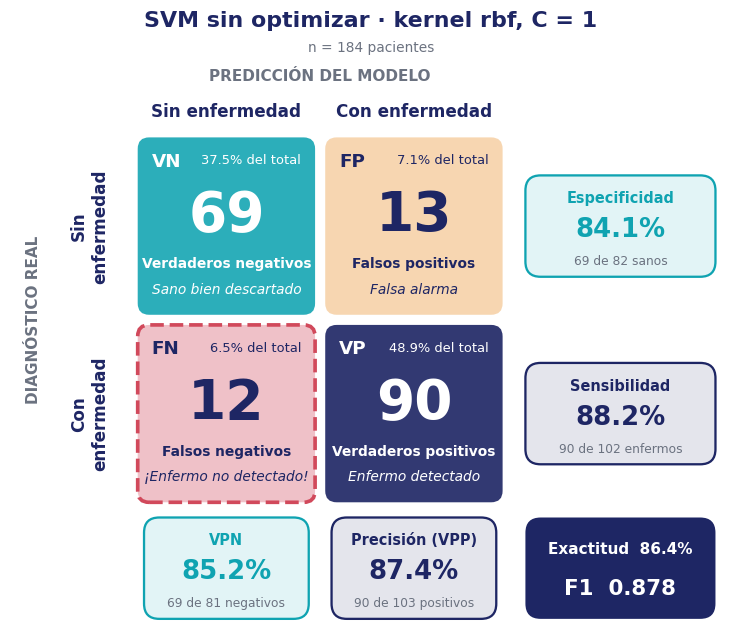

In [28]:
# ✅ VERIFICACIÓN TODO B1
assert isinstance(svm_base, Pipeline), "svm_base debe ser el Pipeline que devuelve crear_pipeline_svm()."
assert hasattr(svm_base.named_steps["modelo"], "support_"), "Falta entrenar el pipeline con .fit(X_train, y_train)."
assert y_pred_svm_base is not None and len(y_pred_svm_base) == len(y_test), "y_pred_svm_base debe calcularse sobre X_test."
assert set(np.unique(y_pred_svm_base)) <= {0, 1}, "y_pred_svm_base debe contener solo 0 y 1."
assert y_proba_svm_base is not None and np.ndim(y_proba_svm_base) == 1 and np.all((y_proba_svm_base >= 0) & (y_proba_svm_base <= 1)), \
    "y_proba_svm_base debe ser un vector de probabilidades → predict_proba(X_test)[:, 1]"
assert metricas_svm_base is not None, "Calcula metricas_svm_base con calcular_metricas."
assert metricas_svm_base["VP"] + metricas_svm_base["FN"] == int(y_test.sum()), \
    "Las métricas deben calcularse sobre PRUEBA (y_test), no sobre entrenamiento."

print(f"Vectores de soporte: {svm_base.named_steps['modelo'].n_support_.sum()} de {len(X_train)} pacientes de entrenamiento")
print(f"Desacuerdos entre predict() y predict_proba() ≥ 0.50: "
      f"{int((y_pred_svm_base != (y_proba_svm_base >= 0.5).astype(int)).sum())} paciente(s)\n")
mostrar_metricas(metricas_svm_base, "SVM con valores por defecto (prueba)")
graficar_matriz_confusion(y_test, y_pred_svm_base, "SVM sin optimizar · kernel rbf, C = 1")
plt.show()

> **🧑‍🏫 Nota docente — TODO B1**
> - En esta ejecución el SVM por defecto deja **12 falsos negativos** y 13 falsas alarmas (F1 = 0.878, AUC = 0.936) frente a los **9 FN** de la regresión logística por defecto (F1 = 0.899). Primera lección útil: *un modelo más sofisticado no empieza ganando*.
> - Pero su **AUC ya es la más alta de las tres familias** (0.936 vs 0.932). Buen momento para separar dos ideas que los alumnos suelen mezclar: **ordenar bien** a los pacientes (AUC) no es lo mismo que **clasificar bien** con el corte en 0.50.
> - El modelo usa **328 de los 734** pacientes de entrenamiento como vectores de soporte (≈ 45 %): señal de que las clases se traslapan bastante, no de un error. Si alguien esperaba "unos pocos puntos en el borde", esta es la oportunidad de aclarar que el margen blando deja dentro a todo paciente mal clasificado o demasiado cerca de la frontera.
> - El contador de desacuerdos `predict` vs `predict_proba ≥ 0.5` suele dar 1 o 2 pacientes. No es un fallo: `predict` usa el signo de la distancia a la frontera y `predict_proba` usa el escalado de Platt, que se ajusta con otra validación cruzada interna. Si alguien pregunta por qué el AUC y la matriz "no se llevan", la respuesta está aquí.
> - Error frecuente: olvidar `.fit()` y suponer que `crear_pipeline_svm()` ya entrena. La verificación lo atrapa con `support_`.

### 🔧 La rejilla del SVM
Aquí aparece una diferencia práctica respecto a la regresión logística: **`gamma` solo existe para el kernel `rbf`**. Si pones ambos kernels y una lista de `gamma` en un mismo diccionario, `GridSearchCV` entrenará el kernel lineal tres veces con resultados idénticos (`gamma` simplemente se ignora) y perderás tiempo de cómputo.

La solución es que `param_grid` también acepta una **lista de diccionarios**: cada diccionario es un bloque independiente de combinaciones y la búsqueda los explora todos.

```python
[{"modelo__kernel": ["linear"], ...},
 {"modelo__kernel": ["rbf"], "modelo__gamma": [...], ...}]
```

### 🔑 TODO B2 — Solución: rejilla del SVM

In [29]:
# 🔑 SOLUCIÓN TODO B2 ───────────────────────────────────────────────────
param_grid_svm = [
    {"modelo__kernel":       ["linear"],              # frontera recta: gamma no aplica
     "modelo__C":            np.logspace(-3, 2, 6),   # 0.001 … 100
     "modelo__class_weight": [None, "balanced"]},

    {"modelo__kernel":       ["rbf"],                 # frontera curva
     "modelo__C":            np.logspace(-3, 2, 6),
     "modelo__gamma":        ["scale", 0.01, 0.1],
     "modelo__class_weight": [None, "balanced"]},
]

In [30]:
# ✅ VERIFICACIÓN TODO B2
_rejillas = param_grid_svm if isinstance(param_grid_svm, list) else [param_grid_svm]
assert all(isinstance(r, dict) for r in _rejillas) and _rejillas, \
    "param_grid_svm debe ser un diccionario o una lista de diccionarios."
_malas = [k for r in _rejillas for k in r if not k.startswith("modelo__")]
assert not _malas, f"Estas claves no llevan el prefijo 'modelo__': {sorted(set(_malas))}"

_valores = {}
for r in _rejillas:
    for k, v in r.items():
        _valores.setdefault(k, []).extend(list(v))
_faltan = [k for k in ["modelo__kernel", "modelo__C", "modelo__gamma", "modelo__class_weight"]
           if k not in _valores]
assert not _faltan, f"Faltan estos hiperparámetros: {_faltan}"

assert {"linear", "rbf"} <= set(_valores["modelo__kernel"]), "Explora los dos kernels: 'linear' y 'rbf'."
_C = np.asarray(_valores["modelo__C"], dtype=float)
assert len(set(_C)) >= 6, f"Incluye al menos 6 valores distintos de C (tienes {len(set(_C))})."
assert _C.min() <= 0.0011 and _C.max() >= 99.9, f"C debe cubrir de 0.001 a 100 (tu rango: {_C.min():g} – {_C.max():g})."
_g_num = [v for v in _valores["modelo__gamma"] if isinstance(v, (int, float)) and not isinstance(v, bool)]
assert "scale" in _valores["modelo__gamma"] and len(set(_g_num)) >= 2, \
    "gamma debe incluir 'scale' y al menos dos valores numéricos."
assert None in _valores["modelo__class_weight"] and "balanced" in _valores["modelo__class_weight"], \
    "class_weight debe incluir None y 'balanced'."
for r in _rejillas:                                    # ¿los nombres existen en el pipeline?
    crear_pipeline_svm().set_params(**{k: list(v)[0] for k, v in r.items()})

_n = sum(int(np.prod([len(list(v)) for v in r.values()])) for r in _rejillas)
print("✅ Rejilla válida")
for i, r in enumerate(_rejillas, 1):
    print(f"   Bloque {i}: " + " · ".join(f"{k.replace('modelo__', '')}({len(list(v))})" for k, v in r.items()))
print(f"\n   {_n} combinaciones × {validacion.get_n_splits()} pliegues = {_n * validacion.get_n_splits()} entrenamientos")
print("   ⏱️ Con probability=True cada entrenamiento ajusta 5 modelos internos más.",
      "\n      Esta búsqueda puede tardar uno o dos minutos: es normal." if _n <= 100
      else "\n      ⚠️ Tu rejilla es muy grande: considera recortarla antes de ejecutar la búsqueda.")

✅ Rejilla válida
   Bloque 1: kernel(1) · C(6) · class_weight(2)
   Bloque 2: kernel(1) · C(6) · gamma(3) · class_weight(2)

   48 combinaciones × 5 pliegues = 240 entrenamientos
   ⏱️ Con probability=True cada entrenamiento ajusta 5 modelos internos más. 
      Esta búsqueda puede tardar uno o dos minutos: es normal.


> **🧑‍🏫 Nota docente — TODO B2**
> - La rejilla de la solución tiene 12 + 36 = **48 combinaciones** (240 entrenamientos, cada uno con 5 ajustes internos por el `probability=True`).
> - Si un alumno mete todo en **un solo diccionario** con los dos kernels y tres `gamma`, la verificación lo acepta (es correcto y funciona) pero entrena 72 combinaciones, 24 de ellas redundantes, y la gráfica de la búsqueda le mostrará tres líneas idénticas para `linear`. Es un momento excelente para mostrar la diferencia en pantalla en vez de explicarla.
> - Error frecuente: escribir `"kernel"` en vez de `"modelo__kernel"`. La verificación lo atrapa antes de perder dos minutos de cómputo.
> - Si el grupo va corto de tiempo, autoriza `np.logspace(-3, 2, 6)` y `gamma = ["scale", 0.1]`: baja a 36 combinaciones sin cambiar el ganador.

### 🔑 TODO B3 — Solución: búsqueda y evaluación del SVM
> Se usa `metrica_busqueda`, la misma métrica elegida en el TODO 3, para que la comparación entre familias sea justa.

In [31]:
# 🔑 SOLUCIÓN TODO B3 ───────────────────────────────────────────────────
# ⏱️ Esta celda puede tardar uno o dos minutos. Es normal.
busqueda_svm = GridSearchCV(estimator=crear_pipeline_svm(),
                            param_grid=param_grid_svm,
                            scoring=metrica_busqueda,      # la misma métrica del TODO 3
                            cv=validacion,
                            n_jobs=-1)
busqueda_svm.fit(X_train, y_train)

mejor_svm        = busqueda_svm.best_estimator_
y_pred_svm_opt   = mejor_svm.predict(X_test)
y_proba_svm_opt  = mejor_svm.predict_proba(X_test)[:, 1]
metricas_svm_opt = calcular_metricas(y_test, y_pred_svm_opt, y_proba_svm_opt)

In [32]:
# ✅ VERIFICACIÓN TODO B3 + comparación justa contra el SVM por defecto
assert isinstance(busqueda_svm, GridSearchCV), "busqueda_svm debe ser un objeto GridSearchCV."
assert hasattr(busqueda_svm, "best_estimator_"), "Falta entrenar la búsqueda con .fit(X_train, y_train)."
assert busqueda_svm.scoring == metrica_busqueda, "Usa la MISMA métrica que en el TODO 3 (metrica_busqueda)."
assert busqueda_svm.n_splits_ == 5, "Usa cv=validacion (5 pliegues estratificados)."
assert mejor_svm is busqueda_svm.best_estimator_, "mejor_svm debe ser busqueda_svm.best_estimator_ (no lo re-entrenes a mano)."
assert metricas_svm_opt is not None and metricas_svm_opt["VP"] + metricas_svm_opt["FN"] == int(y_test.sum()), \
    "Evalúa el ganador sobre PRUEBA con calcular_metricas."

_cv_svm_base = cross_val_score(crear_pipeline_svm(), X_train, y_train, cv=validacion, scoring=metrica_busqueda)
resumen_busqueda(busqueda_svm, "Búsqueda del SVM")
print(f"\n   SVM por defecto (misma VC)  {_cv_svm_base.mean():.4f} ± {_cv_svm_base.std():.4f}")
print()
mostrar_metricas(metricas_svm_opt, "SVM optimizado (prueba)")

── Búsqueda del SVM ────────────────────────────
   48 combinaciones × 5 pliegues = 240 entrenamientos
   Mejor f1 en validación: 0.8756 ± 0.0248
   C                      1.0
   class_weight           balanced
   gamma                  scale
   kernel                 rbf

   SVM por defecto (misma VC)  0.8689 ± 0.0264

── SVM optimizado (prueba) ─────────────────────
   VP=88  FN=14  VN=72  FP=10
   Exactitud         0.870  █████████████████
   Sensibilidad      0.863  █████████████████
   Especificidad     0.878  ██████████████████
   Precisión (VPP)   0.898  ██████████████████
   F1                0.880  ██████████████████
   AUC-ROC           0.937  ███████████████████


In [33]:
# Las 10 mejores combinaciones del SVM
_res_svm = pd.DataFrame(busqueda_svm.cv_results_)
_cols_svm = [c for c in _res_svm.columns if c.startswith("param_")]
top10_svm = (_res_svm.sort_values("rank_test_score")
             [["rank_test_score"] + _cols_svm + ["mean_test_score", "std_test_score"]]
             .rename(columns=lambda c: c.replace("param_modelo__", ""))
             .head(10).reset_index(drop=True))
top10_svm.style.format({"C": "{:.4g}", "mean_test_score": "{:.4f}", "std_test_score": "{:.4f}"}) \
    .background_gradient(subset=["mean_test_score"], cmap="GnBu")

,rank_test_score,C,class_weight,kernel,gamma,mean_test_score,std_test_score
0,1,1,balanced,rbf,scale,0.8756,0.0248
1,2,1,balanced,rbf,0.100000,0.8742,0.0251
2,3,1,nan,rbf,0.100000,0.8707,0.0318
3,4,1,nan,linear,nan,0.8703,0.0317
4,5,1,nan,rbf,scale,0.8689,0.0264
5,6,0.1,balanced,rbf,scale,0.8687,0.0356
6,7,100,nan,linear,nan,0.8679,0.0329
7,8,10,balanced,linear,nan,0.8677,0.0187
8,9,0.1,nan,rbf,0.100000,0.8676,0.0383
9,10,1,balanced,linear,nan,0.8673,0.0208


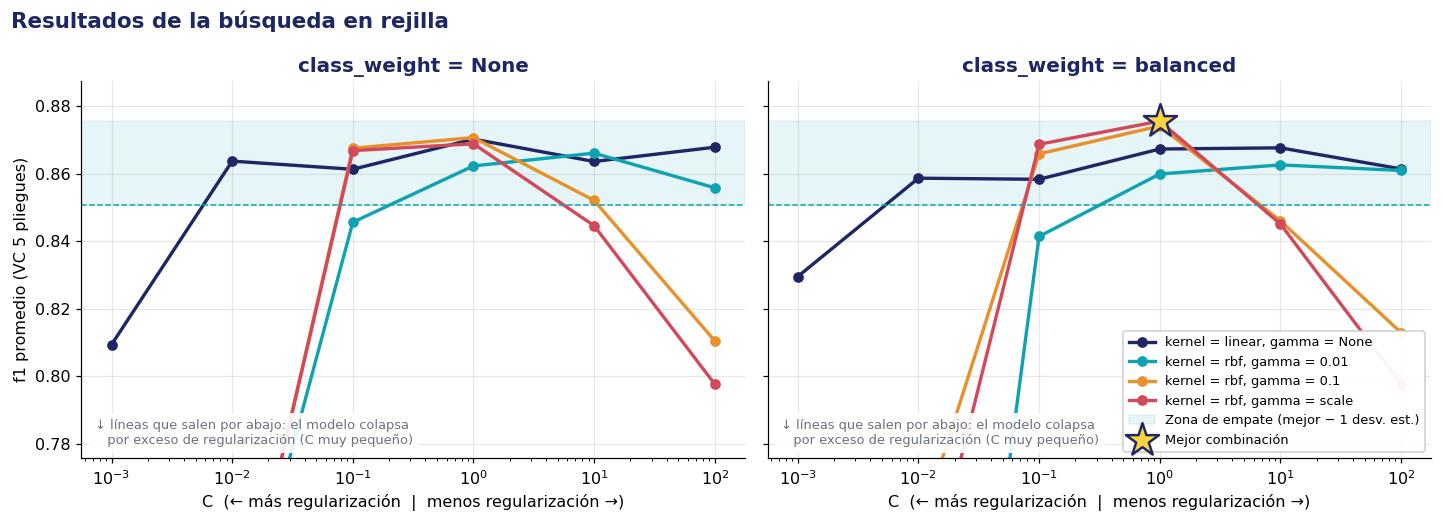

In [34]:
# Reutilizamos la misma gráfica de la Parte A: el eje X vuelve a ser C
graficar_busqueda(busqueda_svm)

> 📈 **Cómo leer esta gráfica:** es la misma función de la Parte A. Cada línea es ahora una combinación de `kernel` y `gamma` (para `linear`, `gamma` aparece como `None` porque ese bloque de la rejilla no lo incluye) y cada panel es un valor de `class_weight`. Fíjate en el extremo izquierdo: las curvas del kernel `rbf` se salen por abajo de la gráfica. Con `C` muy pequeño el SVM se vuelve tan tolerante que deja de distinguir a nadie y manda a **todos** los pacientes a la clase mayoritaria (F1 ≈ 0.71, el mismo colapso que veías en la regresión logística con exceso de regularización). El kernel lineal aguanta bastante mejor ese extremo, porque tiene muchos menos grados de libertad que perder.

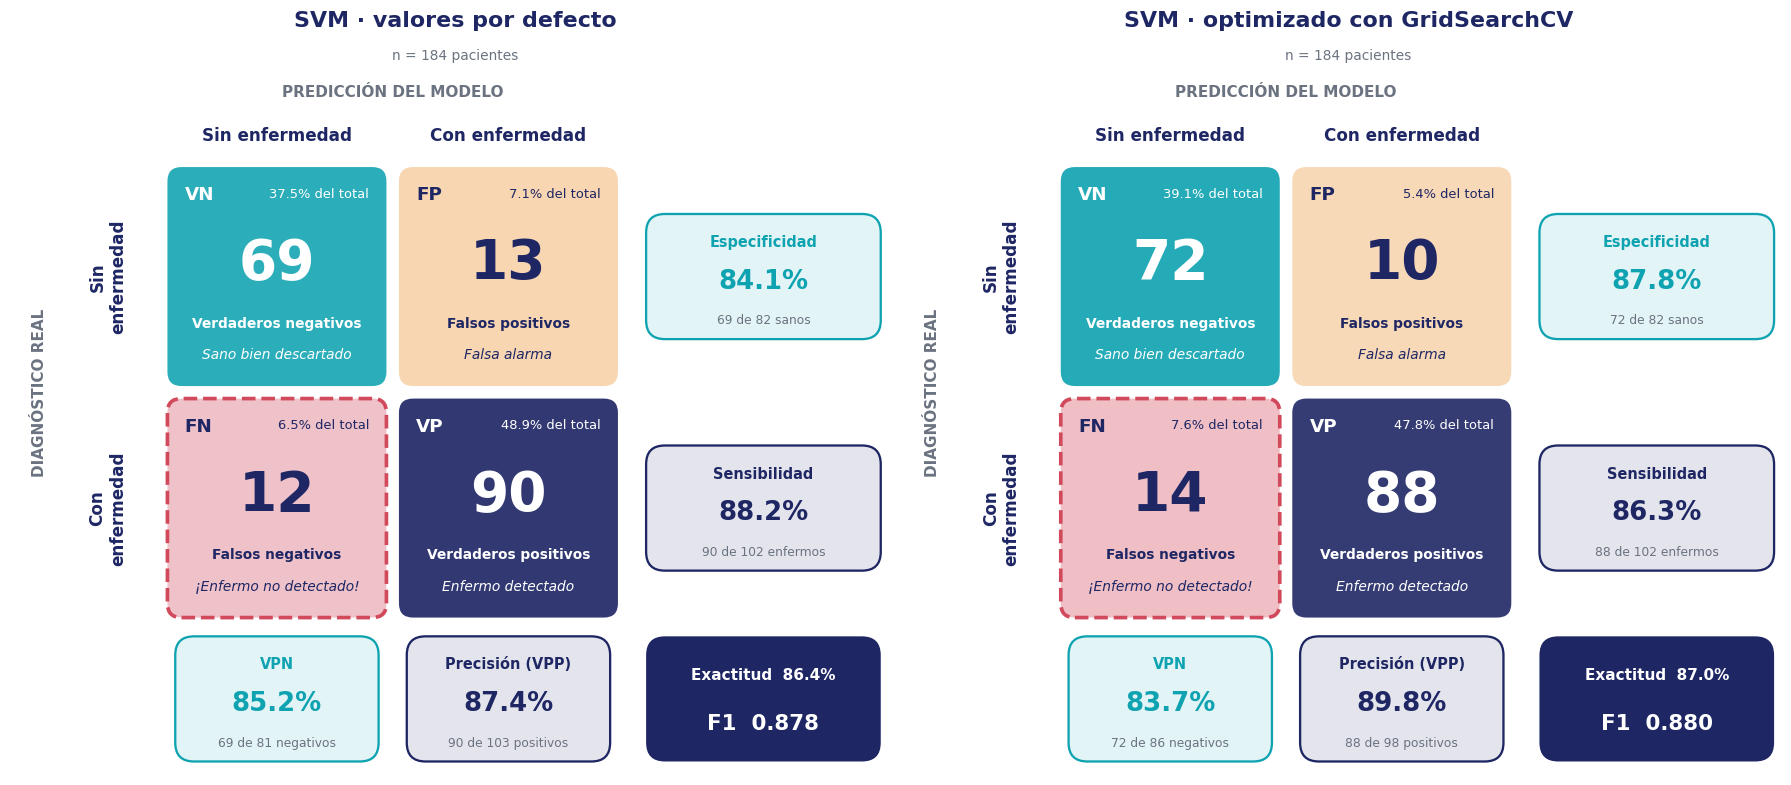

,SVM base,SVM optimizado
Exactitud,0.864,0.87
Sensibilidad,0.882,0.863
Especificidad,0.841,0.878
Precisión (VPP),0.874,0.898
F1,0.878,0.88
AUC-ROC,0.936,0.937
Enfermos no detectados (FN),12,14
Falsas alarmas (FP),13,10


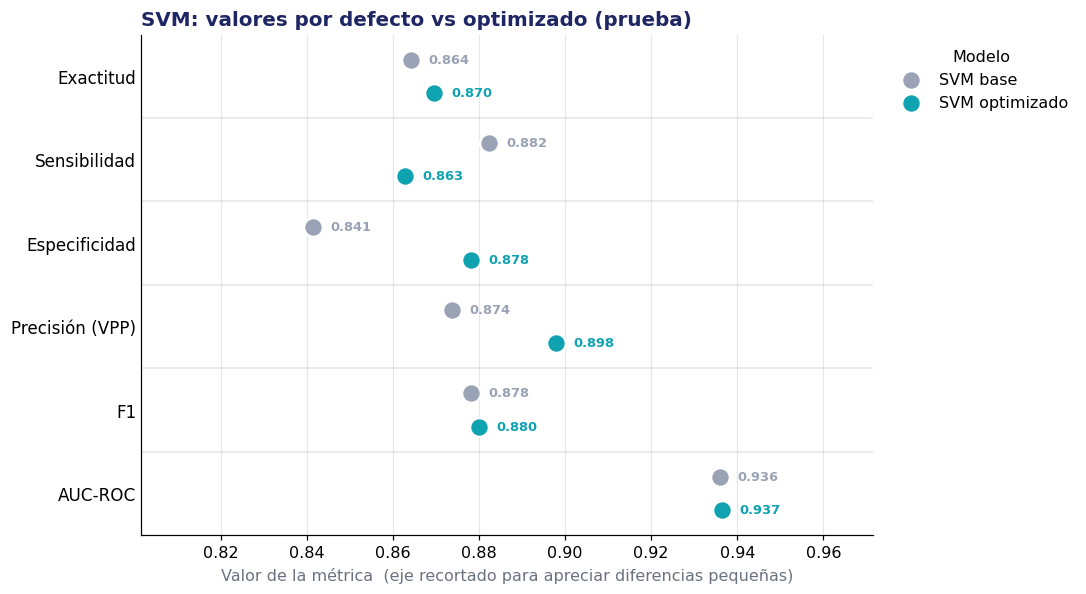

In [35]:
graficar_matrices_lado_a_lado([
    (y_test, y_pred_svm_base, "SVM · valores por defecto"),
    (y_test, y_pred_svm_opt,  "SVM · optimizado con GridSearchCV"),
])

resultados_svm = {"SVM base": metricas_svm_base, "SVM optimizado": metricas_svm_opt}
display(tabla_comparativa(resultados_svm))
graficar_comparacion_metricas(resultados_svm, "SVM: valores por defecto vs optimizado (prueba)")

> **🧑‍🏫 Nota docente — resultados del SVM (ejecución de referencia)**
> - Ganador: **`kernel = 'rbf'`, `C = 1.0`, `gamma = 'scale'`, `class_weight = 'balanced'`**, con F1 de validación **0.876 ± 0.025** frente a **0.869 ± 0.026** del SVM por defecto. La mejora (siete milésimas) vuelve a caer **dentro de la zona de empate**: el mismo mensaje de honestidad de la Parte A, ahora con otra familia.
> - En prueba el resultado es incómodo y por eso vale oro: el SVM optimizado pasa de 12 a **14 falsos negativos** (sensibilidad 0.882 → 0.863) aunque baje las falsas alarmas de 13 a 10 (especificidad 0.841 → 0.878). F1 casi no se mueve (0.878 → 0.880). Es decir: **optimizar una métrica global no garantiza mejorar el error que más importa en la clínica**, y `class_weight='balanced'` no siempre favorece a la clase que uno esperaría — aquí las clases ya estaban casi balanceadas (55/45), así que "balancear" desplaza la frontera por razones de ruido más que de estructura.
> - Pregunta de oro para la clase: *si en validación el ganador era mejor, ¿por qué en prueba detecta menos enfermos?* Respuesta: 184 pacientes de prueba, 102 enfermos; dos pacientes valen ~2 puntos de sensibilidad. Diferencias de esta magnitud no son señal, son ruido de muestreo.
> - El kernel ganador es `rbf` pero con `C = 1` y `gamma = 'scale'`, es decir, la versión **menos agresiva** de la frontera curva: prácticamente una frontera suave. Coincide con lo que ya sabíamos por la regresión logística — este problema es casi lineal.
> - Si alguien pregunta por el AUC: 0.936 → 0.937, el mejor de las tres familias. El SVM **ordena** mejor a los pacientes aunque su matriz con el corte en 0.50 sea peor. Enlaza directo con la Parte 7: este modelo es el mejor candidato para un ajuste de umbral.

---
## B.2 · Naive Bayes gaussiano

### 🧠 La idea
En lugar de trazar una frontera, Naive Bayes le da la vuelta a la pregunta con el **teorema de Bayes**. No se pregunta *"¿qué clase corresponde a este perfil?"*, sino *"**si este paciente estuviera enfermo, ¿qué tan típico sería su perfil?**"*, y lo mismo suponiéndolo sano. Gana la clase que hace más verosímil lo observado, ponderada por qué tan frecuente es esa clase en la población (las **probabilidades a priori**, que aquí son 55 % / 45 %).

Para poder hacer esa cuenta con 11 variables a la vez necesita una suposición fuerte —de ahí el apodo de **ingenuo**—: que, **dentro de cada clase, las variables son independientes entre sí**. Clínicamente es falso: la frecuencia cardiaca máxima y la angina de esfuerzo están relacionadas, y las columnas *one-hot* de `ChestPainType` son mutuamente excluyentes, que es lo contrario de ser independientes. Aun así, el modelo suele **ordenar** pacientes bastante bien; lo que sale mal son sus probabilidades, que tienden a ser **exageradamente seguras** (pegadas a 0 o a 1). Lo veremos con nuestros propios datos más abajo.

`GaussianNB` añade una segunda suposición: que cada variable sigue una **campana de Gauss** dentro de cada clase. Todo su entrenamiento consiste en calcular una media y una varianza por variable y por clase — por eso es, con muchísima diferencia, el modelo más rápido de los tres.

### 🔧 ¿Qué hiperparámetros optimizas en un modelo que casi no tiene?
`GaussianNB` expone solo dos, y uno de ellos (`priors`) casi nunca se toca. Ahí está lo interesante de esta sección: **cuando el modelo no tiene perillas, la perilla que importa suele estar en el preprocesamiento.**

| Hiperparámetro | Dónde vive | Qué controla |
|---|---|---|
| **`var_smoothing`** | `modelo__var_smoothing` | Una fracción de la varianza más grande del conjunto que se **suma a todas las varianzas** antes de calcular probabilidades. Impide que una variable casi constante dentro de una clase —algo habitual en las columnas *one-hot*— decida el diagnóstico con una certeza absurda. Por defecto vale `1e-9`, o sea, prácticamente nada. |
| **Transformación de las numéricas** | `prep__num__escalar` | El paso `escalar` que vive dentro del sub-pipeline `num` del preprocesador. `StandardScaler()` solo centra y escala; `PowerTransformer()` además intenta **volver más normal** cada variable — justo lo que `GaussianNB` da por hecho. |

### 🔗 Prefijos anidados: `prep__num__escalar`
Ya usaste `modelo__C` para llegar a un hiperparámetro del paso `modelo`. La regla se aplica tantas veces como niveles haya: `prep__num__escalar` significa *paso `prep` → bloque `num` del `ColumnTransformer` → paso `escalar` de ese sub-pipeline*. Y como el valor de ese paso es un **objeto**, la rejilla lleva objetos: `[StandardScaler(), PowerTransformer()]`.

> 🔍 Para ver todos los nombres disponibles de un pipeline: `sorted(crear_pipeline_nb().get_params().keys())`.

In [36]:
# ── Pipeline de Naive Bayes: mismo preprocesamiento, distinto modelo (ya resuelto) ──
def crear_pipeline_nb(**hiperparametros):
    """Devuelve un pipeline NUEVO: preprocesamiento + GaussianNB con valores por defecto."""
    return Pipeline([("prep", clone(preprocesador)), ("modelo", GaussianNB(**hiperparametros))])

print("Valor por defecto de var_smoothing:", GaussianNB().var_smoothing)
print("\nAlgunos nombres de hiperparámetros del pipeline:")
for nombre in sorted(crear_pipeline_nb().get_params()):
    if nombre.endswith(("modelo__var_smoothing", "modelo__priors", "num__escalar", "imputar__strategy")):
        print("  ", nombre)

Valor por defecto de var_smoothing: 1e-09

Algunos nombres de hiperparámetros del pipeline:
   modelo__priors
   modelo__var_smoothing
   prep__num__escalar
   prep__num__imputar__strategy


### 🔑 TODO B4 — Solución: Naive Bayes con valores por defecto

In [37]:
# 🔑 SOLUCIÓN TODO B4 ───────────────────────────────────────────────────
nb_base = crear_pipeline_nb()
nb_base.fit(X_train, y_train)

y_pred_nb_base   = nb_base.predict(X_test)
y_proba_nb_base  = nb_base.predict_proba(X_test)[:, 1]
metricas_nb_base = calcular_metricas(y_test, y_pred_nb_base, y_proba_nb_base)

Probabilidades muy extremas (> 0.99 o < 0.01): 77% de los pacientes de prueba
Varianza más pequeña aprendida: 0.0238   |   suavizado sumado (epsilon_): 1.00e-09

── Naive Bayes con valores por defecto (prueba) 
   VP=88  FN=14  VN=70  FP=12
   Exactitud         0.859  █████████████████
   Sensibilidad      0.863  █████████████████
   Especificidad     0.854  █████████████████
   Precisión (VPP)   0.880  ██████████████████
   F1                0.871  █████████████████
   AUC-ROC           0.900  ██████████████████


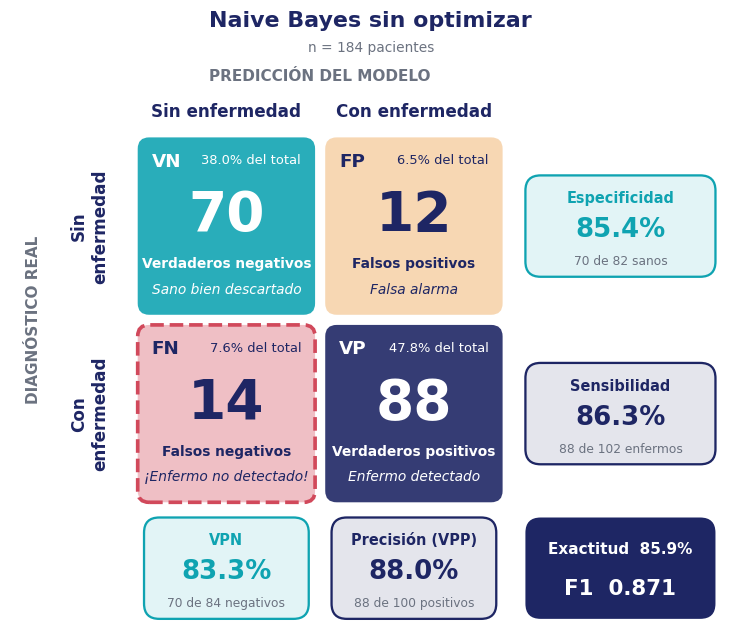

In [38]:
# ✅ VERIFICACIÓN TODO B4
assert isinstance(nb_base, Pipeline), "nb_base debe ser el Pipeline que devuelve crear_pipeline_nb()."
assert hasattr(nb_base.named_steps["modelo"], "var_"), "Falta entrenar el pipeline con .fit(X_train, y_train)."
assert y_pred_nb_base is not None and len(y_pred_nb_base) == len(y_test), "y_pred_nb_base debe calcularse sobre X_test."
assert y_proba_nb_base is not None and np.ndim(y_proba_nb_base) == 1, "y_proba_nb_base → predict_proba(X_test)[:, 1]"
assert metricas_nb_base is not None and metricas_nb_base["VP"] + metricas_nb_base["FN"] == int(y_test.sum()), \
    "Calcula metricas_nb_base sobre PRUEBA con calcular_metricas."

_extremas = float(((y_proba_nb_base > 0.99) | (y_proba_nb_base < 0.01)).mean())
print(f"Probabilidades muy extremas (> 0.99 o < 0.01): {_extremas:.0%} de los pacientes de prueba")
print(f"Varianza más pequeña aprendida: {nb_base.named_steps['modelo'].var_.min():.4f}"
      f"   |   suavizado sumado (epsilon_): {nb_base.named_steps['modelo'].epsilon_:.2e}\n")
mostrar_metricas(metricas_nb_base, "Naive Bayes con valores por defecto (prueba)")
graficar_matriz_confusion(y_test, y_pred_nb_base, "Naive Bayes sin optimizar")
plt.show()

> **🧑‍🏫 Nota docente — TODO B4**
> - Naive Bayes por defecto: **14 FN**, 12 FP, F1 = 0.871 y, sobre todo, **AUC = 0.900**, claramente por debajo de las otras dos familias (0.932 y 0.936). Es el modelo más débil de los tres *y aun así acierta en 86 % de los pacientes*: buen recordatorio de lo poco que dice la exactitud por sí sola.
> - El dato que hay que hacer notar: **77 % de sus probabilidades de prueba son mayores a 0.99 o menores a 0.01**. Compáralo en voz alta con el **0 %** de la regresión logística optimizada y el 1 % del SVM (lo verán en el histograma de más adelante). Naive Bayes casi siempre está "segurísimo", y esa seguridad es un artefacto de multiplicar 20 columnas tratadas como independientes cuando no lo son.
> - `epsilon_` (lo que realmente se suma a cada varianza) vale `var_smoothing × varianza máxima` ≈ `1e-9`, contra una varianza mínima aprendida de ≈ 0.024. Es decir: **el suavizado por defecto no hace absolutamente nada**. Esa observación es la que motiva el TODO B5; si se les señala antes, la búsqueda deja de ser un ritual.
> - Entrena en milisegundos, frente a decenas de segundos del SVM. Vale la pena que los alumnos lo noten en vivo.

### 🔑 TODO B5 — Solución: rejilla de Naive Bayes

In [39]:
# 🔑 SOLUCIÓN TODO B5 ───────────────────────────────────────────────────
param_grid_nb = {
    "modelo__var_smoothing": np.logspace(-9, 0, 10),          # 1e-9 … 1
    "prep__num__escalar":    [StandardScaler(), PowerTransformer()],
}

In [40]:
# ✅ VERIFICACIÓN TODO B5
assert isinstance(param_grid_nb, dict), "param_grid_nb debe ser un diccionario."
_faltan = [k for k in ["modelo__var_smoothing", "prep__num__escalar"] if k not in param_grid_nb]
assert not _faltan, f"Faltan estas claves: {_faltan}  (ojo con el prefijo anidado prep__num__escalar)"

_vs = np.asarray(list(param_grid_nb["modelo__var_smoothing"]), dtype=float)
assert len(_vs) >= 8, f"Incluye al menos 8 valores de var_smoothing (tienes {len(_vs)})."
assert _vs.min() <= 1e-9 * 1.01 and _vs.max() >= 0.999, \
    f"var_smoothing debe ir de 1e-9 a 1 (tu rango: {_vs.min():g} – {_vs.max():g})."
_esc = [type(v).__name__ for v in param_grid_nb["prep__num__escalar"]]
assert "StandardScaler" in _esc and "PowerTransformer" in _esc, \
    "prep__num__escalar debe incluir StandardScaler() y PowerTransformer() (instancias, con paréntesis)."
crear_pipeline_nb().set_params(**{k: list(v)[0] for k, v in param_grid_nb.items()})   # ¿nombres válidos?

_n = int(np.prod([len(list(v)) for v in param_grid_nb.values()]))
print("✅ Rejilla válida")
for k, v in param_grid_nb.items():
    _v = [f"{x:.0e}" if isinstance(x, float) else type(x).__name__ for x in list(v)]
    print(f"   {k:<24} {len(_v):>2} valores: {_v}")
print(f"\n   {_n} combinaciones × {validacion.get_n_splits()} pliegues = {_n * validacion.get_n_splits()} entrenamientos"
      "  (esta vez en segundos)")

✅ Rejilla válida
   modelo__var_smoothing    10 valores: ['1e-09', '1e-08', '1e-07', '1e-06', '1e-05', '1e-04', '1e-03', '1e-02', '1e-01', '1e+00']
   prep__num__escalar        2 valores: ['StandardScaler', 'PowerTransformer']

   20 combinaciones × 5 pliegues = 100 entrenamientos  (esta vez en segundos)


### 🔑 TODO B6 — Solución: búsqueda y evaluación de Naive Bayes

In [41]:
# 🔑 SOLUCIÓN TODO B6 ───────────────────────────────────────────────────
busqueda_nb = GridSearchCV(estimator=crear_pipeline_nb(),
                           param_grid=param_grid_nb,
                           scoring=metrica_busqueda,
                           cv=validacion,
                           n_jobs=-1)
busqueda_nb.fit(X_train, y_train)

mejor_nb        = busqueda_nb.best_estimator_
y_pred_nb_opt   = mejor_nb.predict(X_test)
y_proba_nb_opt  = mejor_nb.predict_proba(X_test)[:, 1]
metricas_nb_opt = calcular_metricas(y_test, y_pred_nb_opt, y_proba_nb_opt)

In [42]:
# ✅ VERIFICACIÓN TODO B6 + comparación justa contra el Naive Bayes por defecto
assert isinstance(busqueda_nb, GridSearchCV), "busqueda_nb debe ser un objeto GridSearchCV."
assert hasattr(busqueda_nb, "best_estimator_"), "Falta entrenar la búsqueda con .fit(X_train, y_train)."
assert busqueda_nb.scoring == metrica_busqueda, "Usa la MISMA métrica que en el TODO 3 (metrica_busqueda)."
assert mejor_nb is busqueda_nb.best_estimator_, "mejor_nb debe ser busqueda_nb.best_estimator_."
assert metricas_nb_opt is not None and metricas_nb_opt["VP"] + metricas_nb_opt["FN"] == int(y_test.sum()), \
    "Evalúa el ganador sobre PRUEBA con calcular_metricas."

_cv_nb_base = cross_val_score(crear_pipeline_nb(), X_train, y_train, cv=validacion, scoring=metrica_busqueda)
resumen_busqueda(busqueda_nb, "Búsqueda de Naive Bayes")
print(f"\n   NB por defecto (misma VC)   {_cv_nb_base.mean():.4f} ± {_cv_nb_base.std():.4f}")
print(f"\n   Suavizado efectivo (epsilon_): {nb_base.named_steps['modelo'].epsilon_:.2e}"
      f"  →  {mejor_nb.named_steps['modelo'].epsilon_:.2e}")
print()
mostrar_metricas(metricas_nb_opt, "Naive Bayes optimizado (prueba)")

── Búsqueda de Naive Bayes ─────────────────────
   20 combinaciones × 5 pliegues = 100 entrenamientos
   Mejor f1 en validación: 0.8634 ± 0.0240
   var_smoothing          0.1
   preproceso · escalar   StandardScaler()

   NB por defecto (misma VC)   0.8444 ± 0.0190

   Suavizado efectivo (epsilon_): 1.00e-09  →  1.00e-01

── Naive Bayes optimizado (prueba) ─────────────
   VP=89  FN=13  VN=73  FP=9
   Exactitud         0.880  ██████████████████
   Sensibilidad      0.873  █████████████████
   Especificidad     0.890  ██████████████████
   Precisión (VPP)   0.908  ██████████████████
   F1                0.890  ██████████████████
   AUC-ROC           0.935  ███████████████████


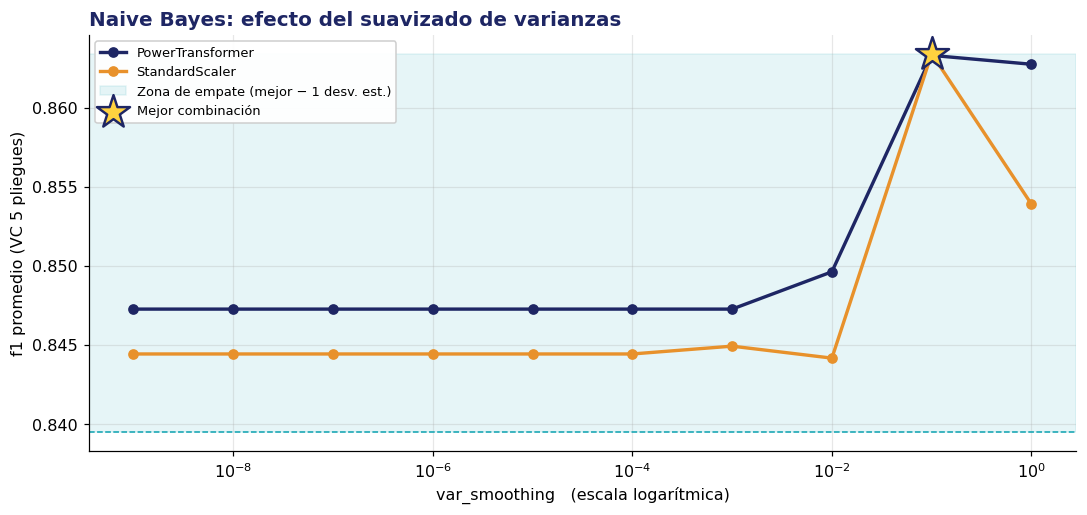

In [43]:
# Aquí el eje X ya no es C, así que usamos la gráfica genérica de la Parte B
graficar_busqueda_generica(busqueda_nb, "modelo__var_smoothing", "prep__num__escalar",
                           titulo="Naive Bayes: efecto del suavizado de varianzas")

> 📈 **Cómo leer esta gráfica:** la curva es **plana** en casi todo el recorrido y solo se levanta al final. Mientras `var_smoothing` sea mucho más pequeño que la varianza más chica que aprendió el modelo, sumarlo no cambia nada — y eso incluye al valor por defecto. El salto aparece cuando el suavizado alcanza ese orden de magnitud: ahí deja de haber variables "casi constantes" capaces de imponer certezas absolutas. Es un ejemplo perfecto de que **el rango de la rejilla importa tanto como la rejilla**: si hubieras explorado solo de `1e-12` a `1e-6`, habrías concluido que este hiperparámetro es irrelevante.

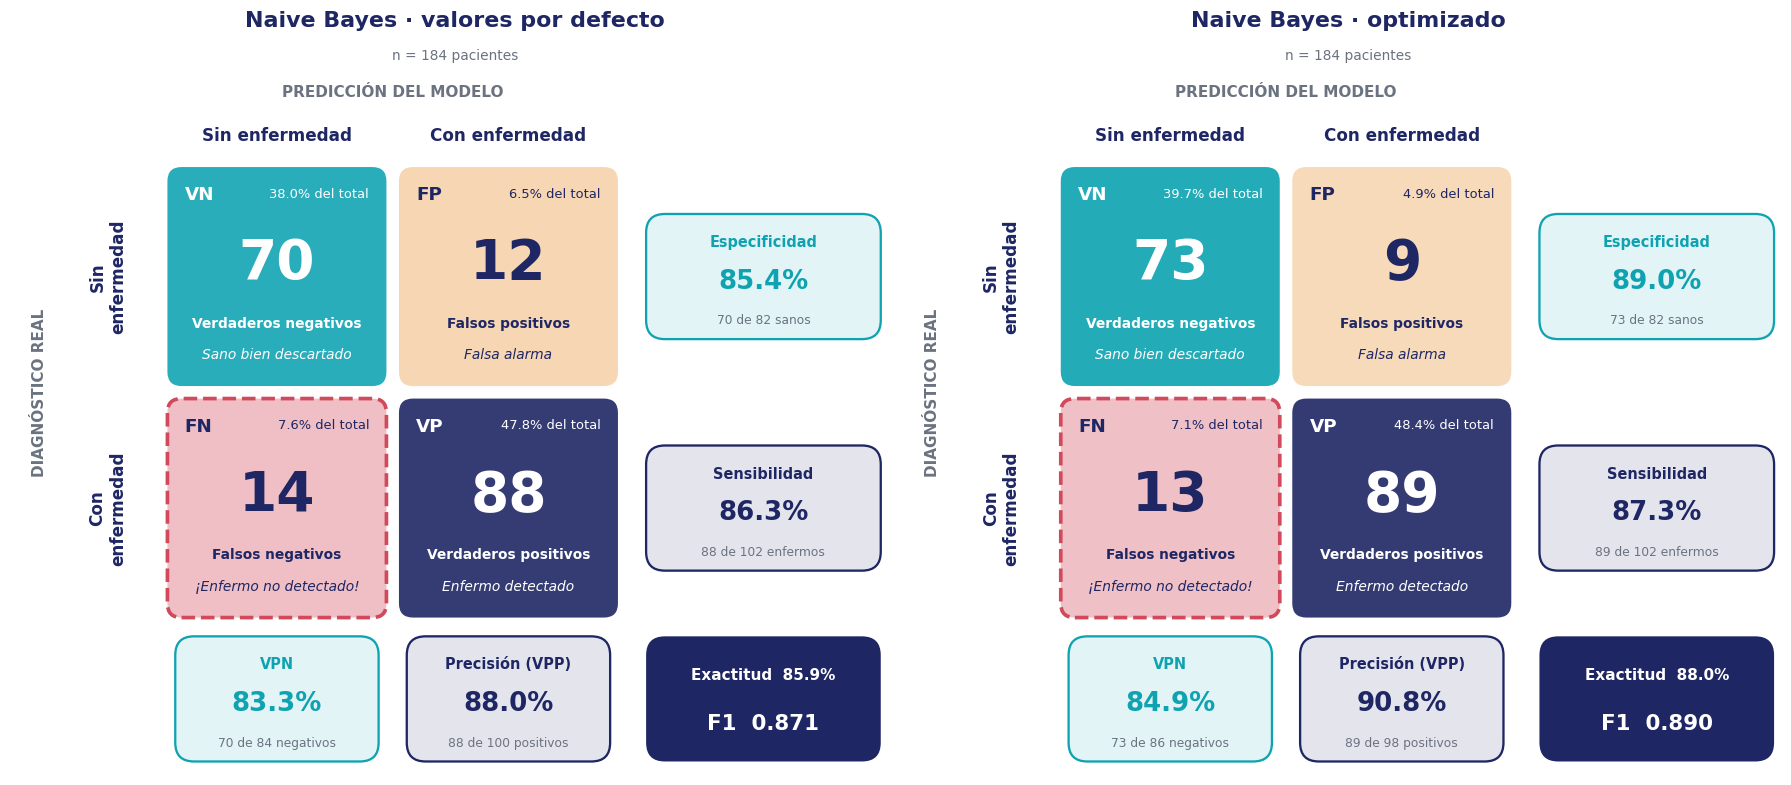

,NB base,NB optimizado
Exactitud,0.859,0.88
Sensibilidad,0.863,0.873
Especificidad,0.854,0.89
Precisión (VPP),0.88,0.908
F1,0.871,0.89
AUC-ROC,0.9,0.935
Enfermos no detectados (FN),14,13
Falsas alarmas (FP),12,9


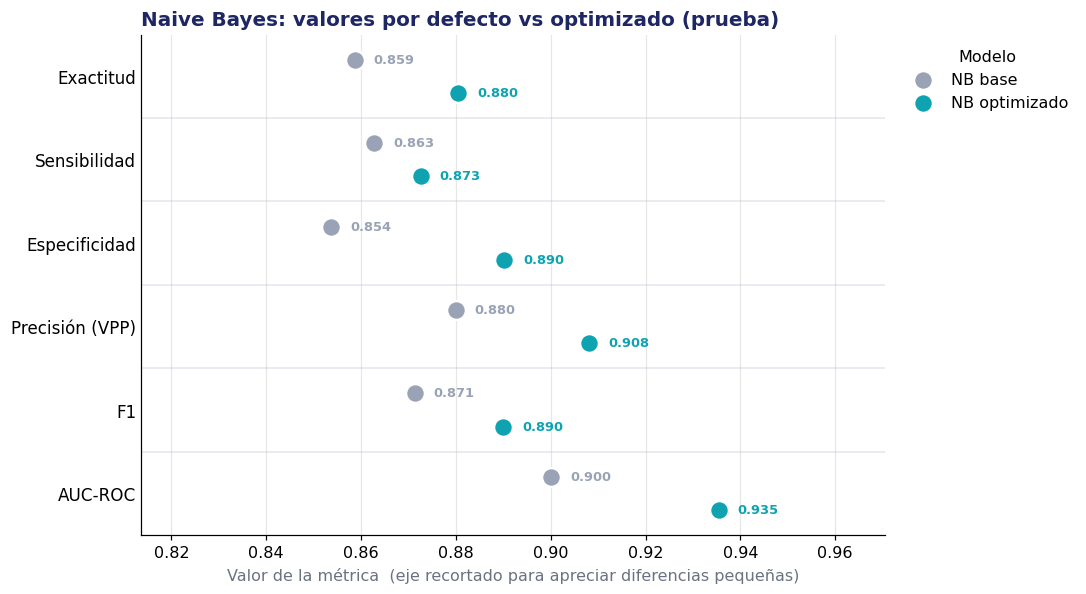

In [44]:
graficar_matrices_lado_a_lado([
    (y_test, y_pred_nb_base, "Naive Bayes · valores por defecto"),
    (y_test, y_pred_nb_opt,  "Naive Bayes · optimizado"),
])

resultados_nb = {"NB base": metricas_nb_base, "NB optimizado": metricas_nb_opt}
display(tabla_comparativa(resultados_nb))
graficar_comparacion_metricas(resultados_nb, "Naive Bayes: valores por defecto vs optimizado (prueba)")

### 🔍 Un vistazo a las probabilidades: ¿qué tan confiable es el número?
Las métricas de la matriz solo miran la decisión final (0 o 1). Pero si el hospital quiere mostrar al médico un número —*"este paciente tiene 78 % de probabilidad"*—, entonces importa también que ese número signifique algo. La siguiente gráfica *(ya resuelta)* muestra **cómo reparte cada modelo sus probabilidades** entre sanos y enfermos.

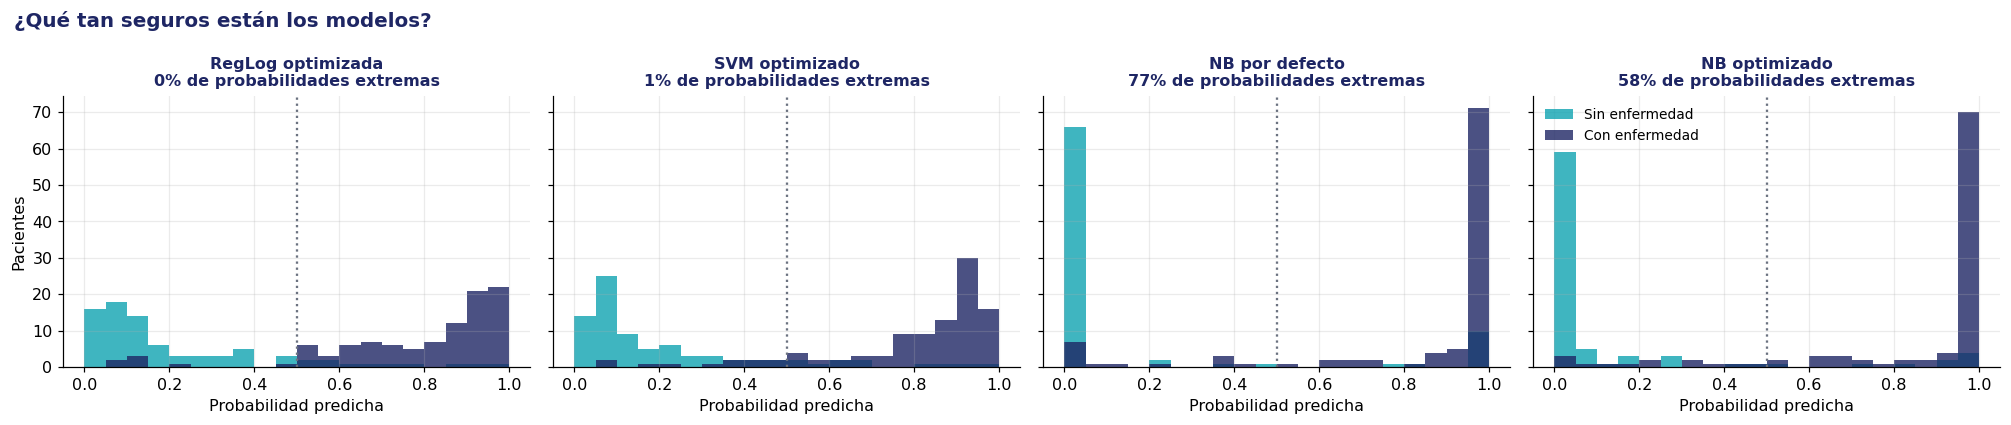

In [45]:
graficar_probabilidades({"RegLog optimizada": mejor_modelo,
                         "SVM optimizado":    mejor_svm,
                         "NB por defecto":    nb_base,
                         "NB optimizado":     mejor_nb},
                        X_test, y_test)

> **🧑‍🏫 Nota docente — resultados de Naive Bayes (ejecución de referencia)**
> - Ganador: **`var_smoothing = 0.1`** con `StandardScaler`, F1 de validación **0.863 ± 0.024** frente a **0.844 ± 0.019** del modelo por defecto. Es la mayor ganancia de las tres familias (casi dos centésimas), pero **ojo con la zona de empate**: con una desviación estándar de 0.024, esa franja cubre toda la rejilla, incluido el modelo por defecto. Con el criterio estricto de la Parte A, tampoco aquí podemos declarar un ganador.
> - Lo que sí distingue a este caso, y conviene decirlo en clase, es que la evidencia es de **otro tipo**: la curva no sube de forma errática, sino que se mantiene plana y da un salto limpio en el mismo punto **con los dos transformadores**, y además el mecanismo se entiende y se puede verificar (`epsilon_` alcanza el orden de la varianza mínima). Un patrón sistemático y explicado pesa más que una diferencia de ranking dentro del ruido, aunque ninguno de los dos sea una prueba formal.
> - En prueba: FN 14 → 13, FP 12 → 9, F1 0.871 → 0.890 y, sobre todo, **AUC 0.900 → 0.935**. Ese salto de AUC es el resultado más vistoso de toda la práctica y tiene una explicación física, no mágica: `epsilon_` pasa de `1e-9` a ≈ `0.1`, del mismo orden que la varianza mínima aprendida (≈ 0.024), así que las columnas *one-hot* casi constantes dejan de imponer certezas absolutas y el modelo recupera capacidad de **ordenar** pacientes.
> - El histograma de probabilidades lo hace visible: las extremas bajan de **77 % a 58 %** de los pacientes. Sigue siendo muchísimo comparado con el 0 % de la regresión logística optimizada. Mensaje para llevarse: *Naive Bayes optimizado es un buen clasificador y sigue siendo un mal estimador de probabilidad*; si el hospital quiere mostrar el porcentaje, hay que calibrarlo (`CalibratedClassifierCV`) o usar otro modelo.
> - `PowerTransformer` queda **empatado** con `StandardScaler` (0.8633 vs 0.8634): los separa una diezmilésima. No presentarlo como "el escalador estándar es mejor"; es un empate técnico y así hay que decirlo. Lo que sí se sostiene es que a `var_smoothing` pequeño `PowerTransformer` va algo mejor (0.847 vs 0.844), justo como predice la teoría: normalizar las variables ayuda a un modelo que supone normalidad.
> - Alumnos que solo exploren `var_smoothing` entre `1e-12` y `1e-6` concluirán que el hiperparámetro no sirve. Es un error instructivo: la rejilla define lo que se puede descubrir.

---
## B.3 · Las tres familias, cara a cara

Todas las versiones se entrenaron con los **mismos** 734 pacientes, se optimizaron con la **misma** métrica y los **mismos** 5 pliegues, y se evalúan sobre los **mismos** 184 pacientes de prueba. Ahora sí, la comparación es limpia.

,RegLog base,RegLog optimizada,SVM base,SVM optimizado,NB base,NB optimizado
Exactitud,0.886000,0.902000,0.864000,0.870000,0.859000,0.880000
Sensibilidad,0.912000,0.931000,0.882000,0.863000,0.863000,0.873000
Especificidad,0.854000,0.866000,0.841000,0.878000,0.854000,0.890000
Precisión (VPP),0.886000,0.896000,0.874000,0.898000,0.880000,0.908000
F1,0.899000,0.913000,0.878000,0.880000,0.871000,0.890000
AUC-ROC,0.932000,0.933000,0.936000,0.937000,0.900000,0.935000
Enfermos no detectados (FN),9,7,12,14,14,13
Falsas alarmas (FP),12,11,13,10,12,9


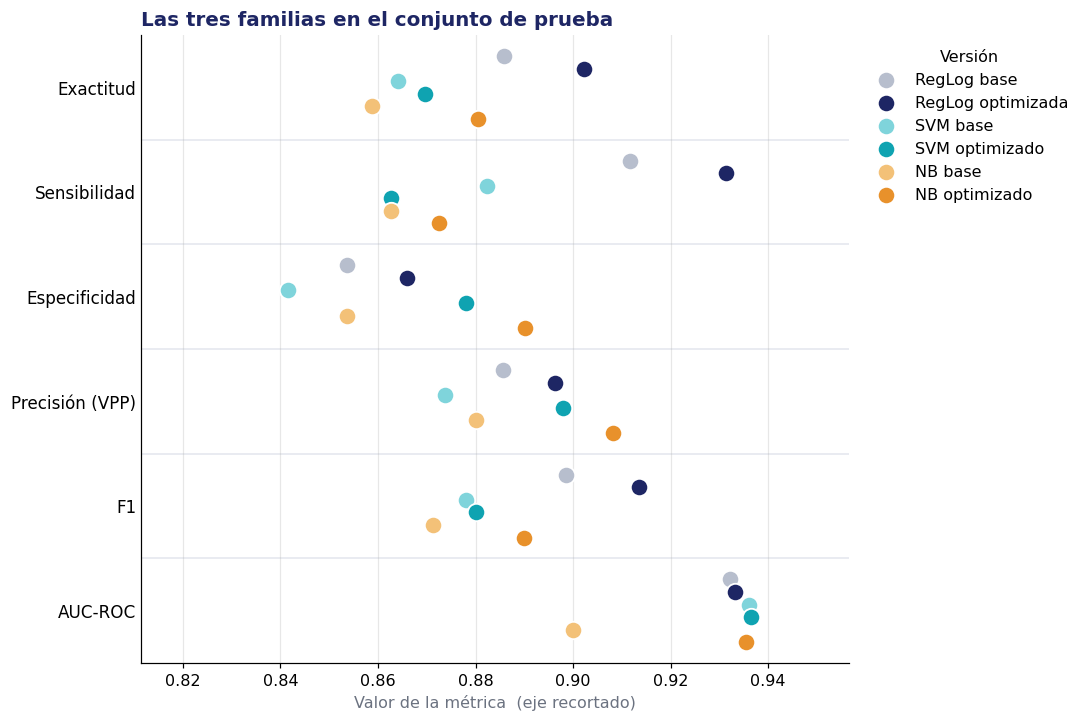

In [46]:
resultados_todos = {
    "RegLog base":      metricas_base,
    "RegLog optimizada": metricas_opt,
    "SVM base":         metricas_svm_base,
    "SVM optimizado":   metricas_svm_opt,
    "NB base":          metricas_nb_base,
    "NB optimizado":    metricas_nb_opt,
}
display(tabla_comparativa(resultados_todos)
        .style.background_gradient(axis=1, cmap="GnBu", subset=pd.IndexSlice[list(ETIQUETAS_METRICAS.values()), :]))
graficar_comparacion_familias(resultados_todos)

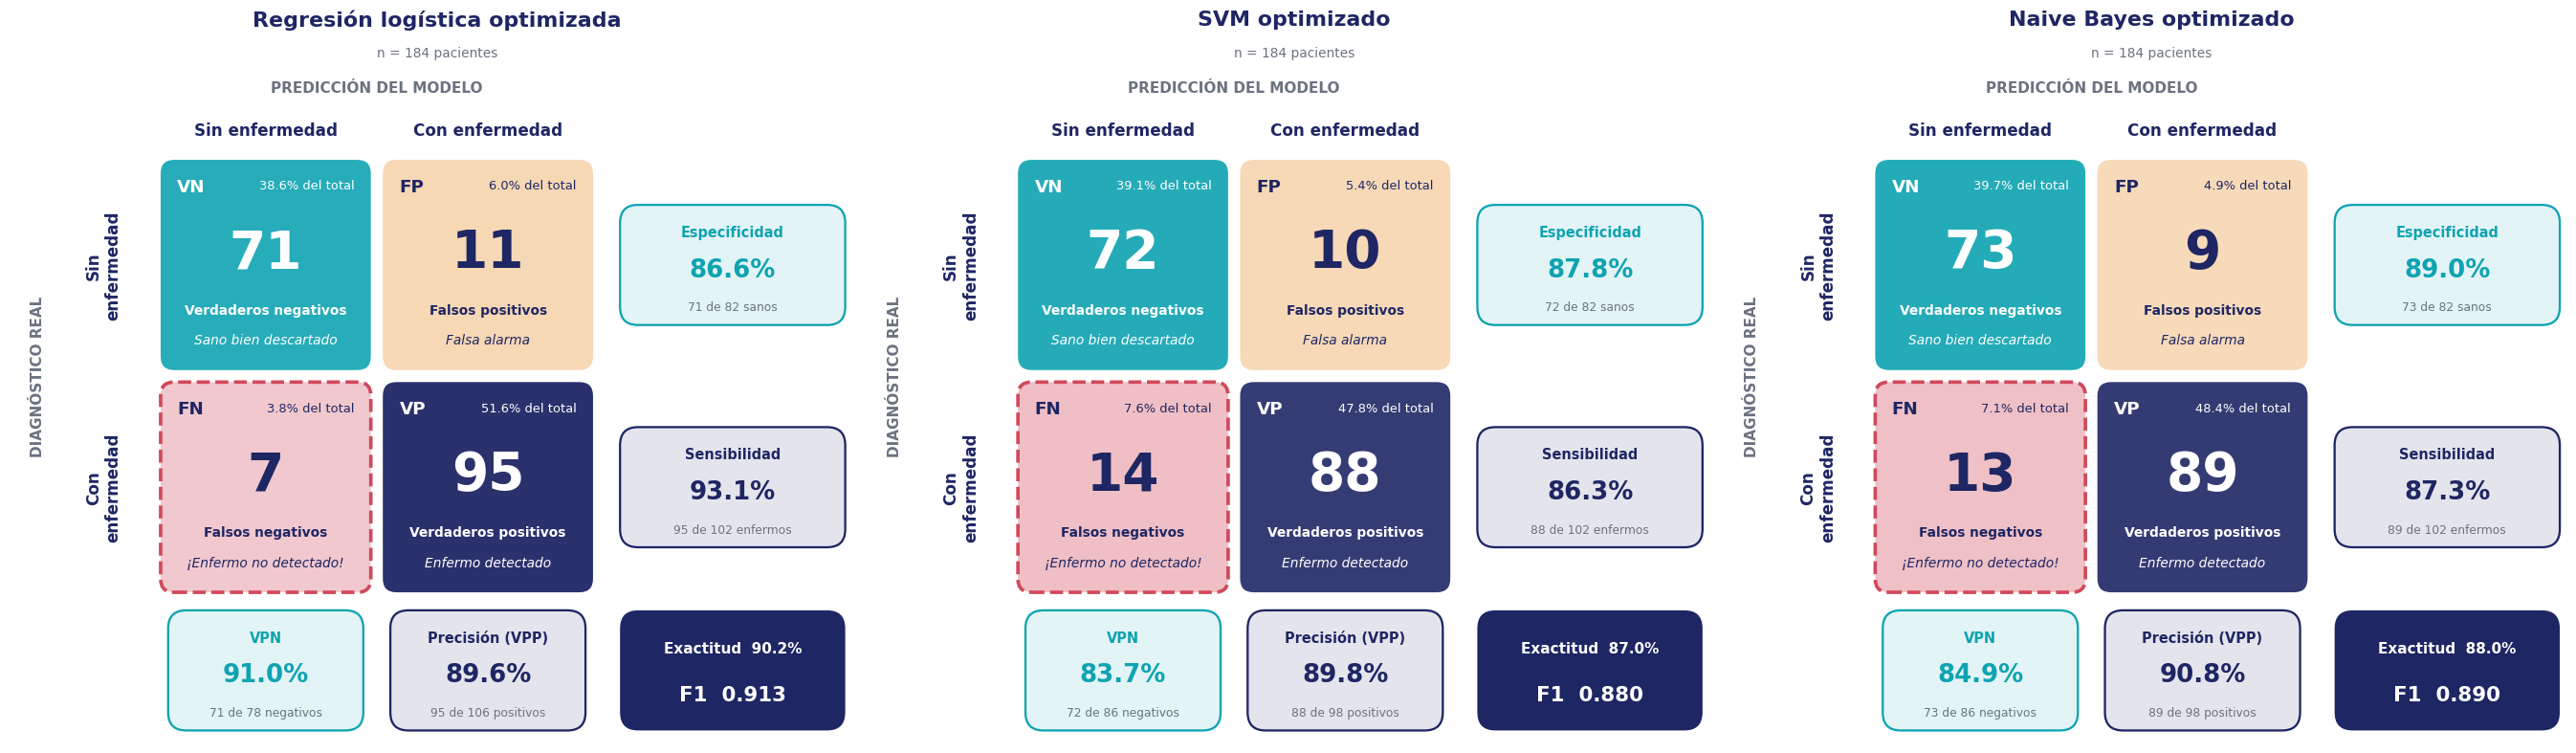

Entrenamientos realizados por cada búsqueda:
   Regresión logística     66 combinaciones × 5 pliegues =  330 modelos
   SVM                     48 combinaciones × 5 pliegues =  240 modelos
   Naive Bayes             20 combinaciones × 5 pliegues =  100 modelos


In [47]:
# Las tres versiones optimizadas, lado a lado
graficar_matrices_lado_a_lado([
    (y_test, y_pred_opt,     "Regresión logística optimizada"),
    (y_test, y_pred_svm_opt, "SVM optimizado"),
    (y_test, y_pred_nb_opt,  "Naive Bayes optimizado"),
])

# ¿Cuánto costó cada búsqueda?
print("Entrenamientos realizados por cada búsqueda:")
for nombre, b in [("Regresión logística", busqueda), ("SVM", busqueda_svm), ("Naive Bayes", busqueda_nb)]:
    n = len(b.cv_results_["params"])
    print(f"   {nombre:<22} {n:>3} combinaciones × {b.n_splits_} pliegues = {n * b.n_splits_:>4} modelos")

---
## B.4 · Preguntas de análisis de la Parte B *(20 pts — 4 pts cada una)*
Responde con **tus propios números**, citando tus tablas y matrices.

**P6.** ¿Qué versión gana en prueba según **F1** y cuál según **AUC**? Si no son la misma, explica cómo puede un modelo **ordenar** mejor a los pacientes y aun así **clasificar** peor con el umbral de 0.50.

**P7.** ¿Qué `kernel`, `C` y `gamma` eligió la búsqueda del SVM? ¿La frontera ganadora resultó recta o curva, y qué te dice eso sobre la estructura del problema clínico?

**P8.** Compara Naive Bayes por defecto contra el optimizado. ¿Qué hizo exactamente un `var_smoothing` grande y por qué cambió tanto el AUC? Apóyate en la gráfica de la búsqueda y en el histograma de probabilidades.

**P9.** Mira la gráfica de probabilidades. Si el hospital quisiera **mostrarle al médico el porcentaje de riesgo** (no solo el sí/no), ¿qué modelo elegirías y por qué? ¿Cambiaría tu respuesta si solo se necesitara una lista ordenada de pacientes para agendar estudios?

**P10.** La suposición "ingenua" de Naive Bayes dice que, dentro de cada clase, las variables son independientes. Nombra **dos variables de este dataset que claramente no lo son** y explica por qué el modelo, aun así, alcanza métricas razonables.

### 🔑 Respuestas modelo de la Parte B (basadas en esta ejecución)

**P6.** En F1 gana la **regresión logística optimizada** (0.913), y en segundo lugar queda la **regresión logística por defecto** (0.899), por delante del Naive Bayes optimizado (0.890), el SVM optimizado (0.880), el SVM por defecto (0.878) y el Naive Bayes por defecto (0.871). En AUC el orden cambia: gana el **SVM optimizado** (0.937), seguido del SVM por defecto (0.936), el Naive Bayes optimizado (0.935) y apenas después las dos regresiones logísticas (0.933 y 0.932); los cuatro primeros están prácticamente empatados. La razón es que **miden cosas distintas**: el AUC evalúa si el modelo le asigna mayor probabilidad a un enfermo que a un sano tomados al azar, es decir, qué tan bien **ordena**, sin importar dónde se corte; F1 evalúa la decisión final tomada **en el umbral 0.50**. Un modelo puede ordenar impecablemente y aun así tener su mejor punto de corte en 0.42 en vez de 0.50: con el corte por defecto se ve peor de lo que es. Consecuencia práctica: el SVM es el mejor candidato para un ajuste de umbral como el de la Parte 7.

**P7.** `kernel = 'rbf'`, `C = 1.0`, `gamma = 'scale'` y `class_weight = 'balanced'`. La frontera ganadora es **curva**, pero en su versión más suave: `gamma='scale'` es el valor más conservador de los explorados y `C = 1` está lejos del extremo de sobreajuste. Además, en la tabla de las 10 mejores combinaciones el kernel **lineal** con `C = 1` aparece a pocas milésimas del ganador, dentro de la zona de empate. Todo apunta a lo mismo: **este problema es esencialmente lineal**, las 11 variables clínicas separan a los pacientes casi con un plano, y por eso la regresión logística —que es lineal— sigue siendo competitiva y mucho más interpretable.

**P8.** Con `var_smoothing = 1e-9` el suavizado efectivo (`epsilon_`) es de `1e-9`, contra una varianza mínima aprendida de ≈ 0.024: no hace nada. Con `var_smoothing = 0.1`, `epsilon_` sube a ≈ 0.1 y se suma a **todas** las varianzas. Lo importante es a quién afecta: a las columnas *one-hot* que dentro de una clase son casi constantes (por ejemplo, casi ningún sano tiene `ST_Slope_Down`). Con varianza casi cero, esas columnas multiplicaban la probabilidad por números absurdamente grandes o pequeños y dominaban la decisión; suavizadas, pasan a aportar evidencia en proporción a lo que realmente informan. Por eso el **AUC sube de 0.900 a 0.935**: el modelo recupera su capacidad de ordenar. En el histograma se ve que las probabilidades extremas bajan del 77 % al 58 % de los pacientes. En la gráfica de la búsqueda, la curva es plana hasta `1e-2` y se levanta en `0.1`.

**P9.** Para **mostrar un porcentaje**, la regresión logística: en prueba no produce **ni una sola** probabilidad extrema: las reparte por todo el rango, y además explica su decisión con coeficientes que un cardiólogo puede leer. El SVM optimizado también sería defendible (solo 1 % de valores extremos, gracias al escalado de Platt), aunque no explique nada. Naive Bayes es el peor candidato para eso: aunque optimizado clasifica bien, el 58 % de sus salidas están pegadas a 0 o 1, así que decirle a un paciente "99.7 % de probabilidad" sería falsear la certeza real del modelo. Si en cambio solo se necesita una **lista ordenada** para agendar estudios, la respuesta cambia: ahí solo importa el orden relativo y el SVM (AUC 0.937) es el mejor, con Naive Bayes optimizado muy cerca; la mala calibración deja de ser un problema porque nadie va a leer el número. *Moraleja: la métrica correcta depende de cómo se va a usar la salida del modelo.*

**P10.** Ejemplos válidos: `MaxHR` y `Age` (la frecuencia cardiaca máxima alcanzable baja con la edad, correlación negativa marcada); `ExerciseAngina` y `Oldpeak` (la angina de esfuerzo suele acompañarse de depresión del segmento ST); `ST_Slope` y `Oldpeak` (miden aspectos del mismo segmento); o cualquier par de columnas *one-hot* de la misma variable, que son mutuamente excluyentes — saber que `ChestPainType_ASY = 1` implica que las otras tres valen 0, la antítesis de la independencia. Funciona de todos modos porque para **clasificar** basta con que el modelo ordene bien las clases, no con que estime bien la probabilidad: al contar dos veces la misma evidencia, Naive Bayes exagera su confianza (probabilidades pegadas a 0 y 1) pero normalmente **no se equivoca de lado**. Es la diferencia entre un modelo mal calibrado y un modelo mal ordenado: Naive Bayes es lo primero, no lo segundo.

### 🚀 Extensiones opcionales (para alumnos adelantados o una tercera sesión)
- **Umbral para el SVM.** Repetir la Parte 7 con `mejor_svm`: es el modelo con mejor AUC, así que es el que más debería ganar al mover el corte. Todo el código se reutiliza cambiando `mejor_modelo` por `mejor_svm`.
- **Calibrar Naive Bayes.** Envolver `mejor_nb` en `CalibratedClassifierCV(..., method="isotonic", cv=validacion)` y volver a dibujar el histograma de probabilidades. Ilustra que clasificación y calibración son problemas distintos.
- **¿Y si votan?** Un `VotingClassifier(voting="soft")` con las tres familias. Buen cierre para discutir si el promedio de tres modelos mediocres supera al mejor de ellos (aquí, con un problema casi lineal, la ganancia es mínima: otra lección de honestidad).

### 📝 Rúbrica de la Parte B (100 pts)

| Criterio | Pts | Puntaje completo | Deducciones típicas |
|---|:---:|---|---|
| TODO B1 · SVM por defecto | 10 | Entrena con `X_train`, evalúa en prueba, usa `calcular_metricas` | −5 si evalúa en entrenamiento; −3 si usa `predict` para el AUC |
| TODO B2 · Rejilla del SVM | 15 | Cumple los 4 requisitos; separa `gamma` del kernel lineal | −4 si mete `gamma` al bloque lineal (correcto pero derrochador); −5 por requisito faltante |
| TODO B3 · Búsqueda del SVM | 15 | `GridSearchCV` con `metrica_busqueda`, `cv=validacion`, evalúa `best_estimator_` | −10 si entrena con prueba; −5 si cambia de métrica sin justificar |
| TODO B4 · NB por defecto | 10 | Igual que B1 con `crear_pipeline_nb()` | Mismas deducciones que B1 |
| TODO B5 · Rejilla de NB | 15 | Rango que llega hasta 1 y prefijo anidado correcto | −7 si el rango no pasa de `1e-6` (no vería el efecto); −5 si pasa clases en vez de instancias |
| TODO B6 · Búsqueda de NB | 15 | Igual que B3 | Mismas deducciones que B3 |
| Preguntas P6–P10 | 20 | Cita números propios y distingue ordenar (AUC) de clasificar (F1) | −2 por respuesta genérica sin datos; −4 por respuesta ausente |
| Notebook sin ejecutar o con errores | — | — | −10 |

> **Ponderación sugerida del curso:** Parte A y Parte B valen 100 puntos cada una. Si la práctica se entrega como una sola, promediar ambas o usar 60 % A / 40 % B, ya que la Parte B reutiliza el andamiaje construido en la A.